# 07 - Seed Sensitivity Analysis
Aggregate MLP/LSTM/PatchTST results across multiple seeds and visualize mean ? std.


In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('saved_results')
SEEDS = [42, 123, 2024]
METRICS = [
    'overall_mae',
    'warm_mae',
    'cold_mae',
    'overall_cvrmse',
    'overall_wape'
]
DISPLAY_STRATEGIES = [
    '1. FTL', '2. Personalized-FL', '3. Progressive Unfreezing',
    '4. Instance-TL', '5. Fed-SimTL', '6. FedMetaTL'
]

print('Results dir:', RESULTS_DIR.resolve())
print('Seeds:', SEEDS)


Results dir: E:\PhD\FTL_Smart_Buildings_Energy_Prediction\saved_results
Seeds: [42, 123, 2024]


In [29]:
# Load standardized seed summaries
pattern = re.compile(r'^(mlp|lstm|patchtst)_seed_(\d+)_summary\.csv$', re.IGNORECASE)
frames = []
for p in RESULTS_DIR.glob('*_seed_*_summary.csv'):
    m = pattern.match(p.name)
    if not m:
        continue
    model = m.group(1).upper().replace('PATCHTST', 'PatchTST')
    seed = int(m.group(2))
    if seed not in SEEDS:
        continue
    df = pd.read_csv(p)
    if 'model' not in df.columns:
        df['model'] = model
    if 'seed' not in df.columns:
        df['seed'] = seed
    frames.append(df)

if not frames:
    raise FileNotFoundError('No standardized seed summary CSVs found. Run export cells in 03/04/06 first.')

all_seed_results = pd.concat(frames, ignore_index=True)
all_seed_results['model'] = all_seed_results['model'].replace({'MLP':'MLP','LSTM':'LSTM','PATCHTST':'PatchTST'})
all_seed_results = all_seed_results.sort_values(['model','strategy','seed']).reset_index(drop=True)
print('Loaded rows:', len(all_seed_results))
display(all_seed_results.head(20))


Loaded rows: 81


,model,seed,strategy,overall_mae,warm_mae,cold_mae,overall_cvrmse,overall_wape
0,LSTM,42,0. Local-only,0.272174,0.247943,0.369098,29.245550,21.388803
1,LSTM,123,0. Local-only,0.298146,0.237475,0.540831,29.337521,21.489798
2,LSTM,2024,0. Local-only,0.298596,0.238627,0.538472,30.118286,22.501463
3,LSTM,42,1. FTL,0.337549,0.316038,0.423593,68.408852,64.560204
4,LSTM,123,1. FTL,0.304517,0.292606,0.352159,49.796799,45.853382
5,LSTM,2024,1. FTL,0.223464,0.213984,0.261382,26.566648,21.948486
6,LSTM,42,1b. FedAvg (No Pretrain),0.345487,0.330534,0.405300,36.357658,30.317602
7,LSTM,123,1b. FedAvg (No Pretrain),0.581098,0.549640,0.706930,109.581612,104.458359
8,LSTM,2024,1b. FedAvg (No Pretrain),0.575669,0.546364,0.692885,97.593651,92.789474
9,LSTM,42,2. Personalized-FL,0.670397,0.601822,0.944699,48.525902,43.336353


In [30]:
# Aggregate mean/std over seeds
required_cols = {'model', 'seed', 'strategy', *METRICS}
missing = [c for c in required_cols if c not in all_seed_results.columns]
if missing:
    raise ValueError(f'Missing columns for aggregation: {missing}')

for metric in METRICS:
    agg = (all_seed_results
           .groupby(['model', 'strategy'])[metric]
           .agg(['mean', 'std', 'count'])
           .reset_index())

    agg.columns = [
        'model',
        'strategy',
        f'{metric}_mean',
        f'{metric}_std',
        'n_seeds'
    ]

    agg = agg[agg['strategy'].isin(DISPLAY_STRATEGIES)]
    agg = agg.sort_values(['model', 'strategy']).reset_index(drop=True)

    print(f'\nMetric: {metric}')
    display(agg)

    out_path = RESULTS_DIR / f'seed_agg_{metric}.csv'
    agg.to_csv(out_path, index=False)
    print('Saved:', out_path)


Metric: overall_mae


,model,strategy,overall_mae_mean,overall_mae_std,n_seeds
0,LSTM,1. FTL,0.288510,0.058703,3
1,LSTM,2. Personalized-FL,0.696555,0.087955,3
2,LSTM,3. Progressive Unfreezing,0.300293,0.052708,3
3,LSTM,4. Instance-TL,0.121330,0.013756,3
4,LSTM,5. Fed-SimTL,0.118331,0.005138,3
5,LSTM,6. FedMetaTL,0.288302,0.059124,3
6,MLP,1. FTL,0.298988,0.061260,3
7,MLP,2. Personalized-FL,0.523703,0.045149,3
8,MLP,3. Progressive Unfreezing,0.298253,0.046654,3
9,MLP,4. Instance-TL,0.160933,0.007336,3


Saved: saved_results\seed_agg_overall_mae.csv

Metric: warm_mae


,model,strategy,warm_mae_mean,warm_mae_std,n_seeds
0,LSTM,1. FTL,0.274209,0.053456,3
1,LSTM,2. Personalized-FL,0.658097,0.130614,3
2,LSTM,3. Progressive Unfreezing,0.287781,0.052599,3
3,LSTM,4. Instance-TL,0.113303,0.010094,3
4,LSTM,5. Fed-SimTL,0.109043,0.006710,3
5,LSTM,6. FedMetaTL,0.276680,0.054259,3
6,MLP,1. FTL,0.288855,0.063083,3
7,MLP,2. Personalized-FL,0.514031,0.052050,3
8,MLP,3. Progressive Unfreezing,0.293952,0.046079,3
9,MLP,4. Instance-TL,0.164594,0.012696,3


Saved: saved_results\seed_agg_warm_mae.csv

Metric: cold_mae


...

Saved: saved_results\seed_agg_cold_mae.csv

Metric: overall_cvrmse


,model,strategy,overall_cvrmse_mean,overall_cvrmse_std,n_seeds
0,LSTM,1. FTL,48.257433,20.963533,3
1,LSTM,2. Personalized-FL,54.886133,6.250994,3
2,LSTM,3. Progressive Unfreezing,36.649546,6.923782,3
3,LSTM,4. Instance-TL,17.597294,2.110005,3
4,LSTM,5. Fed-SimTL,15.504983,1.043250,3
5,LSTM,6. FedMetaTL,43.209058,8.676777,3
6,MLP,1. FTL,33.140590,5.413028,3
7,MLP,2. Personalized-FL,52.867633,4.673122,3
8,MLP,3. Progressive Unfreezing,34.378791,4.384268,3
9,MLP,4. Instance-TL,19.221102,0.396403,3


Saved: saved_results\seed_agg_overall_cvrmse.csv

Metric: overall_wape


,model,strategy,overall_wape_mean,overall_wape_std,n_seeds
0,LSTM,1. FTL,44.120691,21.358635,3
1,LSTM,2. Personalized-FL,49.326631,6.024215,3
2,LSTM,3. Progressive Unfreezing,30.907494,7.259436,3
3,LSTM,4. Instance-TL,13.051524,1.716206,3
4,LSTM,5. Fed-SimTL,11.797422,0.896701,3
5,LSTM,6. FedMetaTL,37.923848,8.920137,3
6,MLP,1. FTL,27.687571,5.176466,3
7,MLP,2. Personalized-FL,45.740332,5.041339,3
8,MLP,3. Progressive Unfreezing,29.189316,4.104375,3
9,MLP,4. Instance-TL,15.370060,0.562704,3


Saved: saved_results\seed_agg_overall_wape.csv


In [31]:
# Publication table: average +/- standard deviation over seeds
METRIC_LABELS = {
    'overall_mae': 'Overall MAE',
    'warm_mae': 'Warm MAE',
    'cold_mae': 'Cold MAE',
    'overall_cvrmse': 'CVRMSE (%)',
    'overall_wape': 'WAPE (%)',
}

def mean_std_text(mean, std, digits=3):
    if pd.isna(mean):
        return ''
    if pd.isna(std):
        return f'{mean:.{digits}f}'
    return f'{mean:.{digits}f} +/- {std:.{digits}f}'

summary_rows = []
for (model, strategy), d in all_seed_results.groupby(['model', 'strategy']):
    row = {
        'Model': model,
        'Strategy': strategy,
        'Seeds': ', '.join(str(int(s)) for s in sorted(d['seed'].dropna().unique())),
        'N seeds': int(d['seed'].nunique()),
    }
    for metric in METRICS:
        row[METRIC_LABELS[metric]] = mean_std_text(d[metric].mean(), d[metric].std(ddof=1), digits=3)
        row[f'{metric}_mean'] = d[metric].mean()
        row[f'{metric}_std'] = d[metric].std(ddof=1)
    summary_rows.append(row)

seed_mean_std_table = pd.DataFrame(summary_rows)
model_order = ['MLP', 'LSTM', 'PatchTST']
strategy_order = [
    'C. Centralized',
    '0. Local-only',
    '1b. FedAvg (No Pretrain)',
    '1. FTL',
    '2. Personalized-FL',
    '3. Progressive Unfreezing',
    '4. Instance-TL',
    '5. Fed-SimTL',
    '6. FedMetaTL',
]
seed_mean_std_table['Model'] = pd.Categorical(seed_mean_std_table['Model'], categories=model_order, ordered=True)
seed_mean_std_table['Strategy'] = pd.Categorical(seed_mean_std_table['Strategy'], categories=strategy_order, ordered=True)
seed_mean_std_table = seed_mean_std_table.sort_values(['Model', 'Strategy']).reset_index(drop=True)
seed_mean_std_table['Model'] = seed_mean_std_table['Model'].astype(str)
seed_mean_std_table['Strategy'] = seed_mean_std_table['Strategy'].astype(str)

display_cols = ['Model', 'Strategy', 'Seeds', 'N seeds'] + list(METRIC_LABELS.values())
display(seed_mean_std_table[display_cols])

csv_path = RESULTS_DIR / 'seed_mean_std_publication_table.csv'
tex_path = RESULTS_DIR / 'seed_mean_std_publication_table.tex'
seed_mean_std_table[display_cols].to_csv(csv_path, index=False)
latex_df = seed_mean_std_table[display_cols].copy()
for col in METRIC_LABELS.values():
    latex_df[col] = latex_df[col].str.replace('+/-', r'$\\pm$', regex=False)

def latex_escape(value):
    text = str(value)
    text = text.replace('\\', r'\\textbackslash{}')
    for old, new in {'_': r'\\_', '%': r'\\%', '&': r'\\&', '#': r'\\#'}.items():
        text = text.replace(old, new)
    return text.replace('$\\\\pm$', r'$\\pm$')

with open(tex_path, 'w', encoding='utf-8') as f:
    f.write('\\begin{table}[htbp]\n\\centering\n')
    f.write('\\caption{Average performance across random seeds reported as mean $\\\\pm$ standard deviation.}\n')
    f.write('\\label{tab:seed_mean_std_results}\n')
    f.write('\\begin{tabular}{llrrccccc}\n\\hline\n')
    f.write(' & '.join(latex_escape(c) for c in display_cols) + r' \\ \hline' + '\n')
    for _, row in latex_df.iterrows():
        f.write(' & '.join(latex_escape(row[c]) for c in display_cols) + r' \\' + '\n')
    f.write('\\hline\n\\end{tabular}\n\\end{table}\n')

print('Saved:', csv_path)
print('Saved:', tex_path)

expected = set(SEEDS)
available = (all_seed_results.groupby(['model', 'strategy'])['seed']
             .apply(lambda s: set(int(x) for x in s.dropna().unique()))
             .reset_index(name='available_seeds'))
missing_seed_rows = []
for _, r in available.iterrows():
    missing = sorted(expected - r['available_seeds'])
    if missing:
        missing_seed_rows.append({
            'model': r['model'],
            'strategy': r['strategy'],
            'missing_seeds': missing,
        })

if missing_seed_rows:
    print('\nWarning: some model/strategy rows do not include all requested seeds:')
    display(pd.DataFrame(missing_seed_rows))


,Model,Strategy,Seeds,N seeds,Overall MAE,Warm MAE,Cold MAE,CVRMSE (%),WAPE (%)
0,MLP,C. Centralized,"42, 123, 2024",3,0.137 +/- 0.017,0.124 +/- 0.017,0.186 +/- 0.022,16.443 +/- 1.509,12.625 +/- 1.417
1,MLP,0. Local-only,"42, 123, 2024",3,0.263 +/- 0.005,0.193 +/- 0.006,0.542 +/- 0.008,28.966 +/- 0.477,22.737 +/- 0.433
2,MLP,1b. FedAvg (No Pretrain),"42, 123, 2024",3,0.326 +/- 0.028,0.309 +/- 0.025,0.393 +/- 0.053,39.133 +/- 3.157,33.671 +/- 3.457
3,MLP,1. FTL,"42, 123, 2024",3,0.299 +/- 0.061,0.289 +/- 0.063,0.340 +/- 0.056,33.141 +/- 5.413,27.688 +/- 5.176
4,MLP,2. Personalized-FL,"42, 123, 2024",3,0.524 +/- 0.045,0.514 +/- 0.052,0.562 +/- 0.024,52.868 +/- 4.673,45.740 +/- 5.041
5,MLP,3. Progressive Unfreezing,"42, 123, 2024",3,0.298 +/- 0.047,0.294 +/- 0.046,0.315 +/- 0.049,34.379 +/- 4.384,29.189 +/- 4.104
6,MLP,4. Instance-TL,"42, 123, 2024",3,0.161 +/- 0.007,0.165 +/- 0.013,0.146 +/- 0.021,19.221 +/- 0.396,15.370 +/- 0.563
7,MLP,5. Fed-SimTL,"42, 123, 2024",3,0.150 +/- 0.004,0.151 +/- 0.005,0.148 +/- 0.031,17.948 +/- 1.000,14.042 +/- 0.720
8,MLP,6. FedMetaTL,"42, 123, 2024",3,0.306 +/- 0.031,0.301 +/- 0.033,0.325 +/- 0.026,32.575 +/- 1.313,26.993 +/- 1.047
9,LSTM,C. Centralized,"42, 123, 2024",3,0.116 +/- 0.016,0.114 +/- 0.016,0.125 +/- 0.016,17.596 +/- 3.417,13.088 +/- 3.113


Saved: saved_results\seed_mean_std_publication_table.csv
Saved: saved_results\seed_mean_std_publication_table.tex


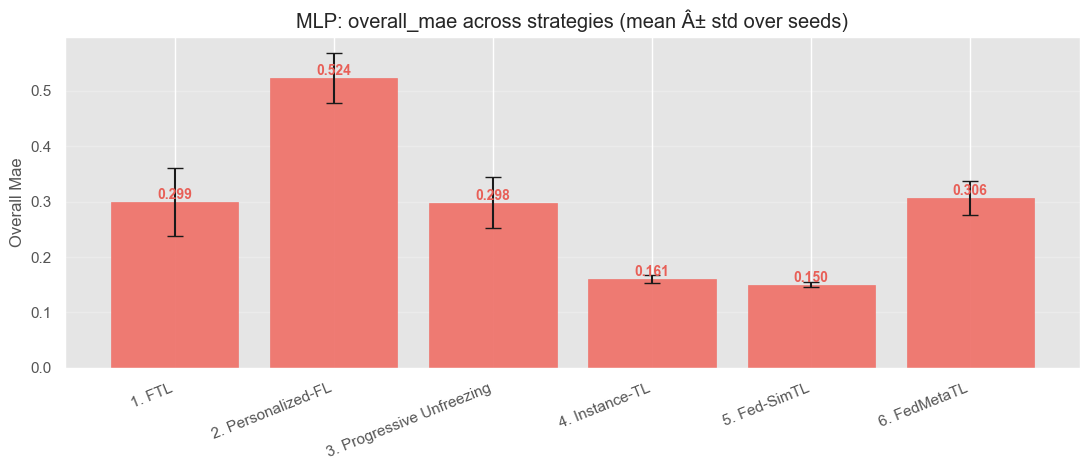

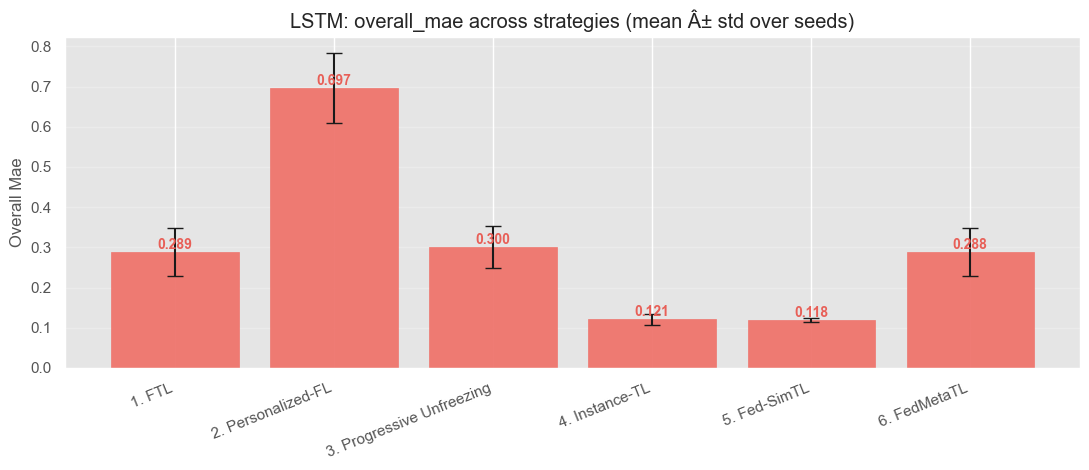

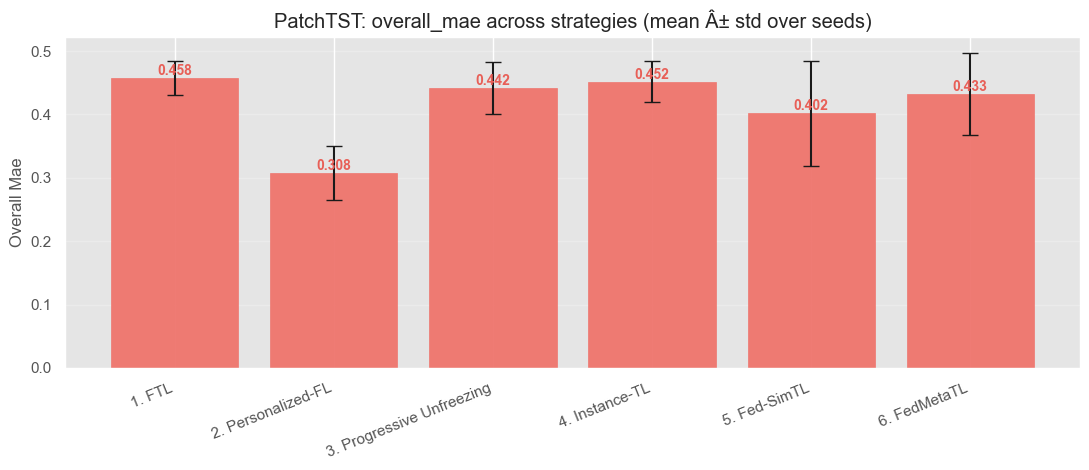

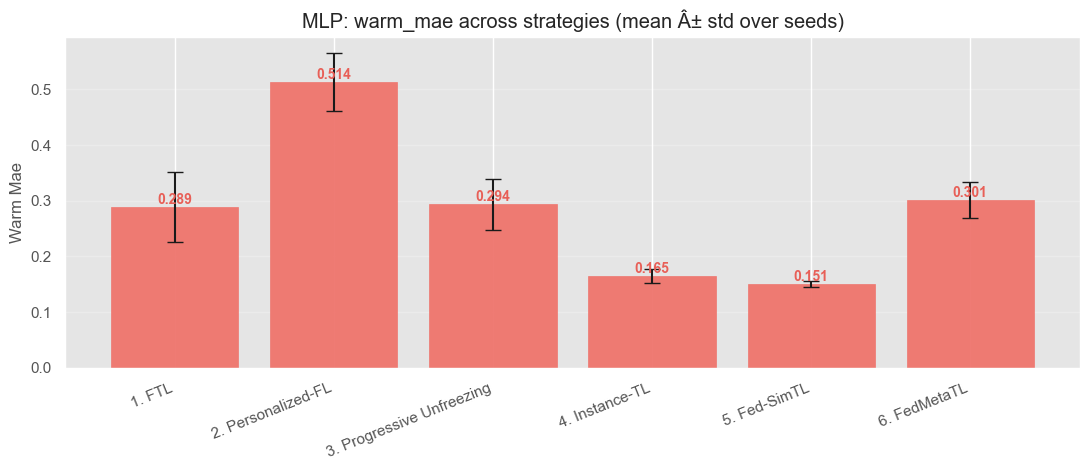

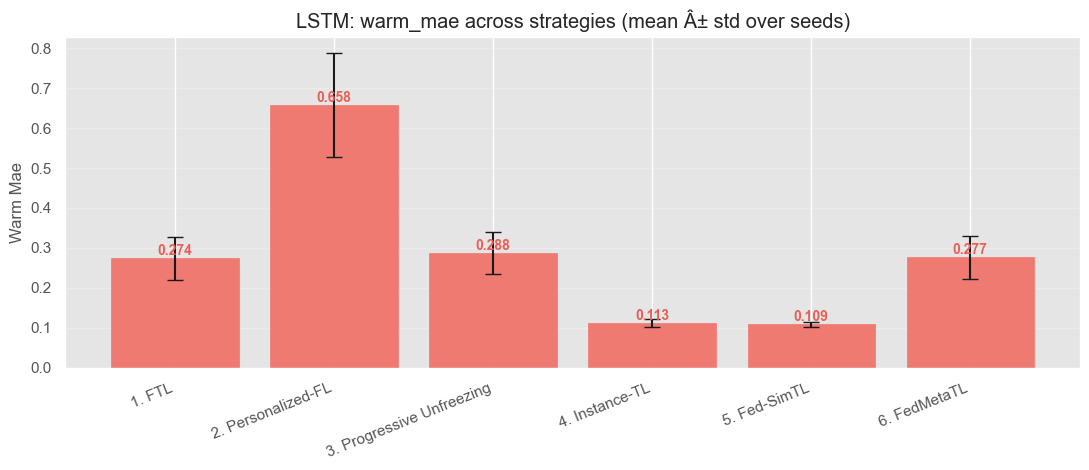

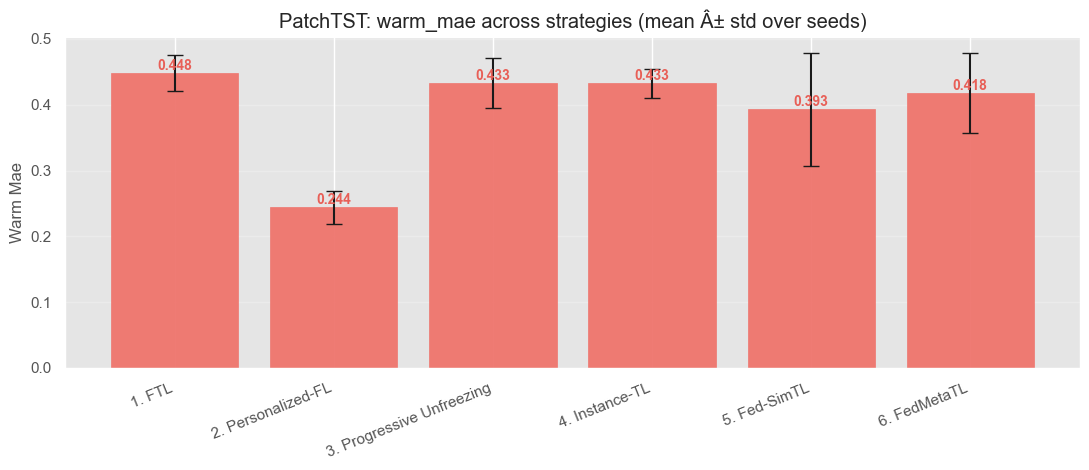

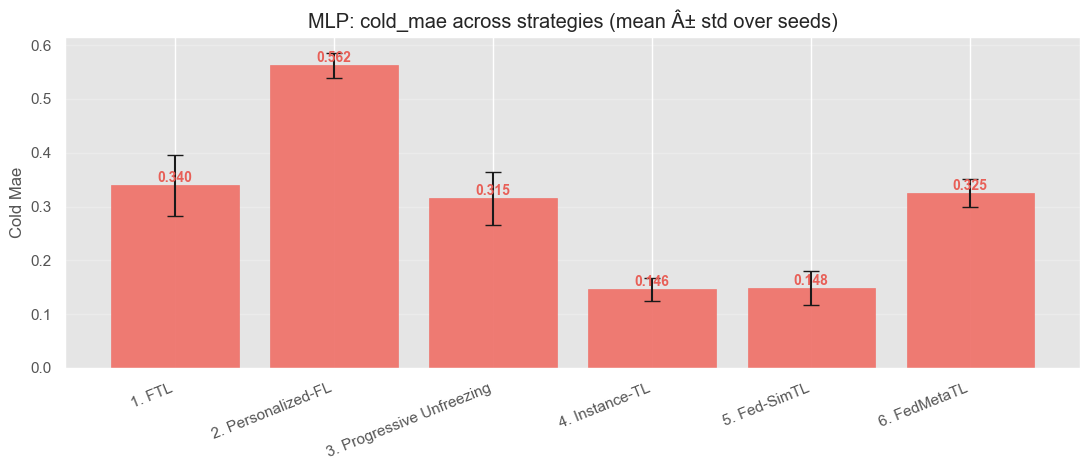

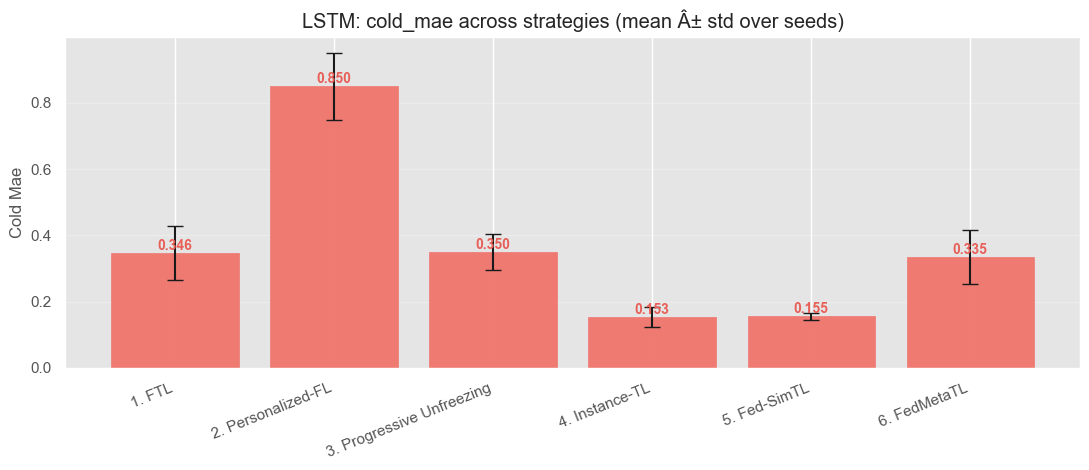

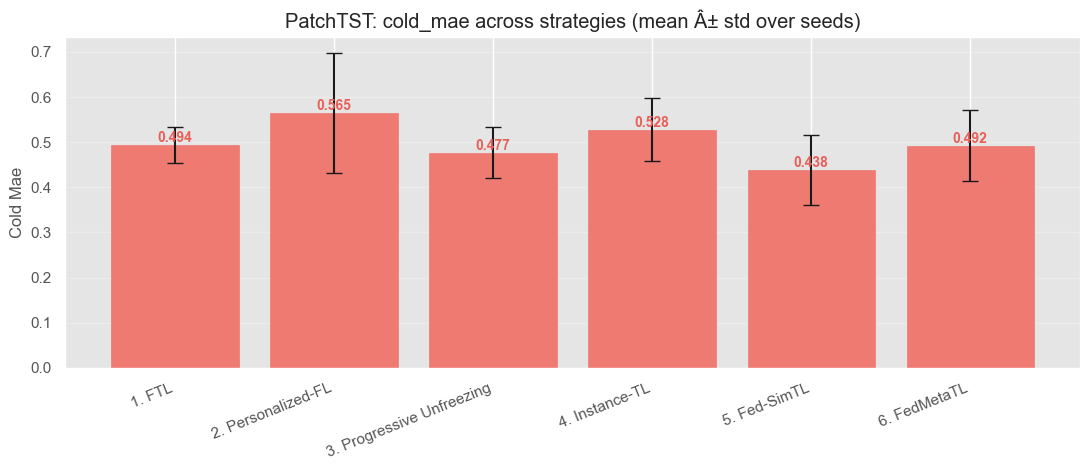

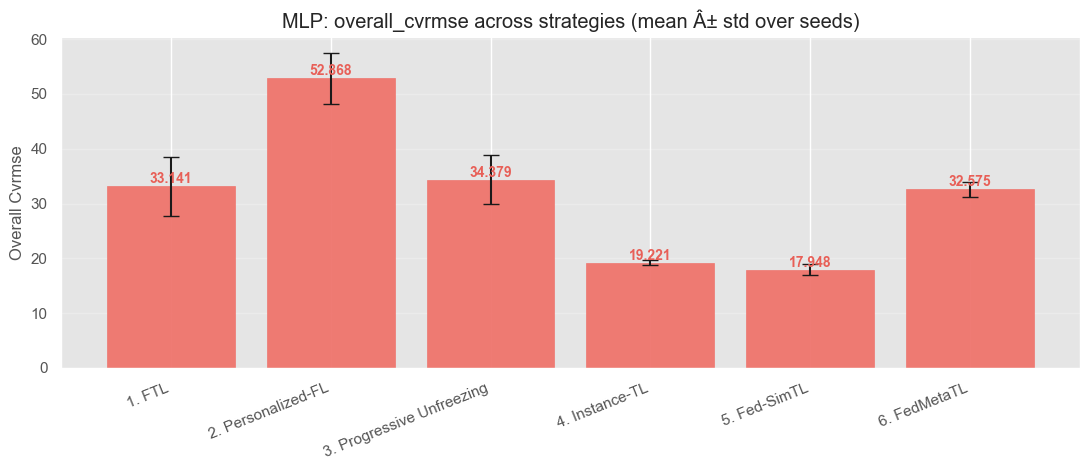

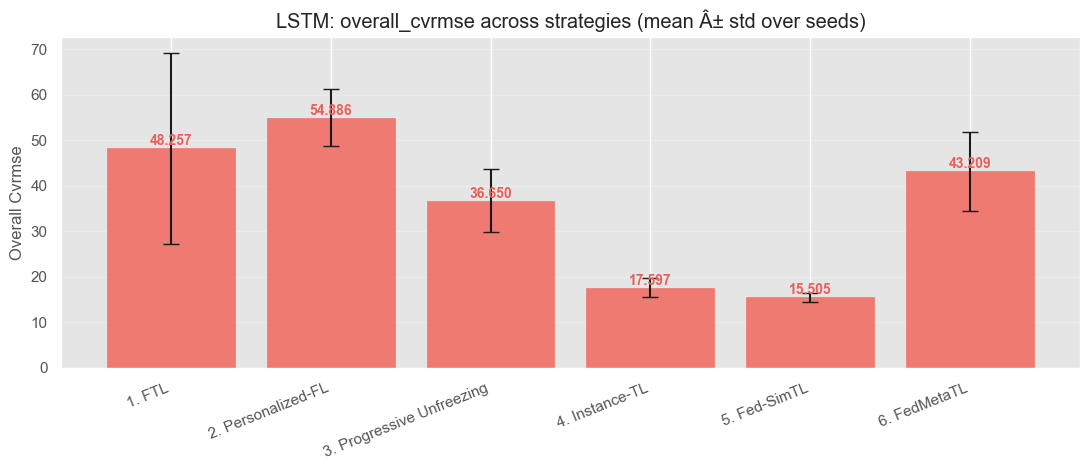

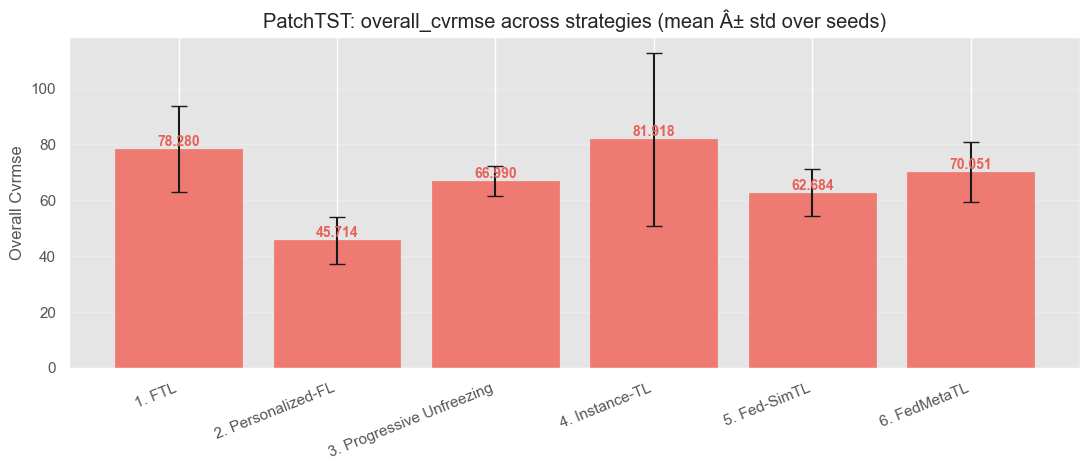

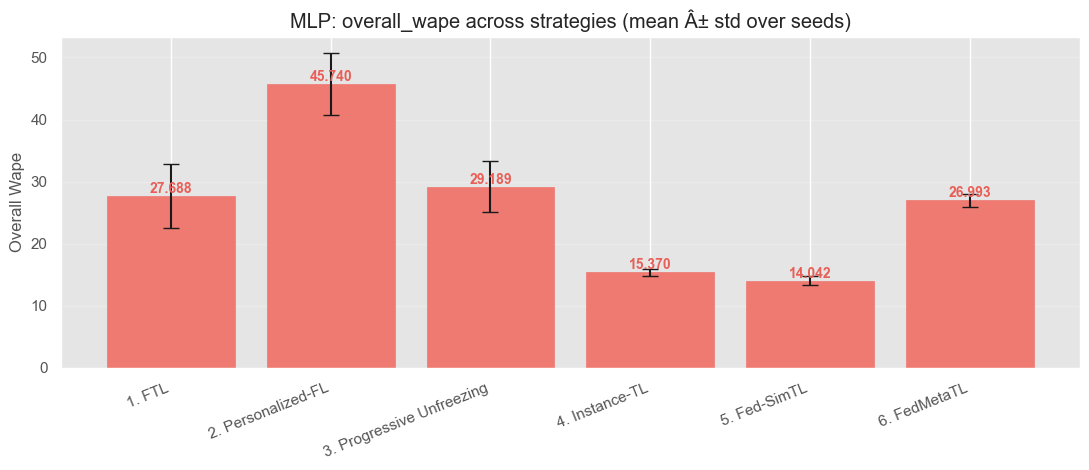

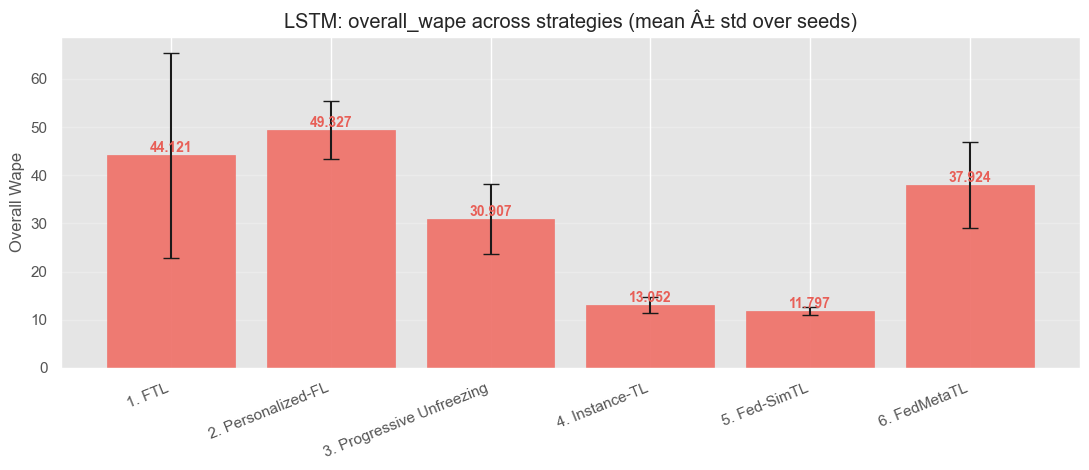

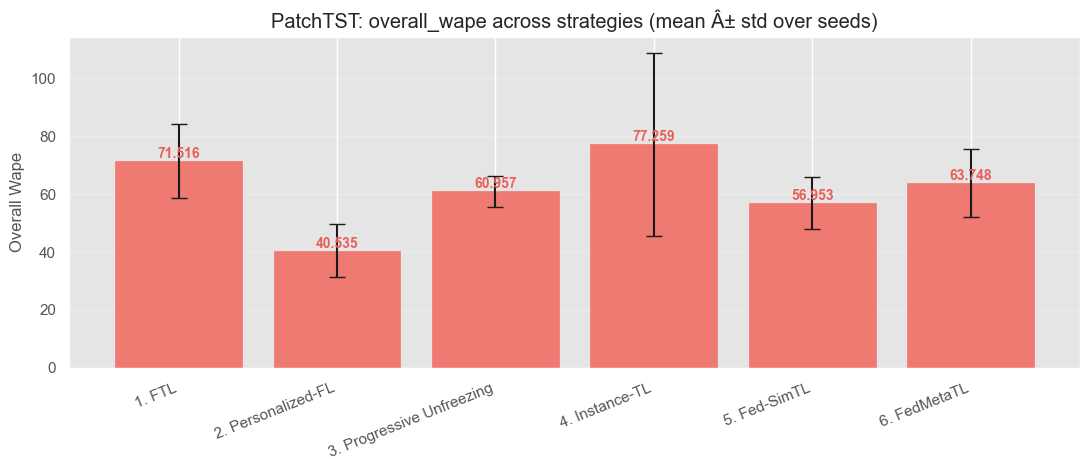

In [33]:

# Plot 1: per-model bars over strategies (mean Â± std across seeds)

models = ['MLP', 'LSTM', 'PatchTST']

for metric in METRICS:

    # Load the corresponding aggregated dataframe
    agg = pd.read_csv(RESULTS_DIR / f'seed_agg_{metric}.csv')

    for model in models:

        d = agg[agg['model'] == model].copy()

        if d.empty:
            continue

        d['strategy'] = pd.Categorical(
            d['strategy'],
            categories=DISPLAY_STRATEGIES,
            ordered=True
        )

        d = d.sort_values('strategy')

        plt.figure(figsize=(11, 4.8))

        x = np.arange(len(d))
        y = d[f'{metric}_mean'].values
        e = np.nan_to_num(d[f'{metric}_std'].values, nan=0.0)

        plt.bar(
            x,
            y,
            yerr=e,
            capsize=6,
            color='#ef746c',
            edgecolor='#ef746c',
            alpha=0.95
        )

        # value labels
        for xi, yi in zip(x, y):
            plt.text(
                xi,
                yi,
                f'{yi:.3f}',
                ha='center',
                va='bottom',
                fontsize=10,
                color='#e85f57',
                fontweight='bold'
            )

        plt.xticks(x, d['strategy'], rotation=22, ha='right')

        plt.ylabel(metric.replace('_', ' ').title())

        plt.title(
            f'{model}: {metric} across strategies '
            f'(mean Â± std over seeds)'
        )

        plt.grid(axis='y', alpha=0.25)

        plt.tight_layout()
        plt.show()


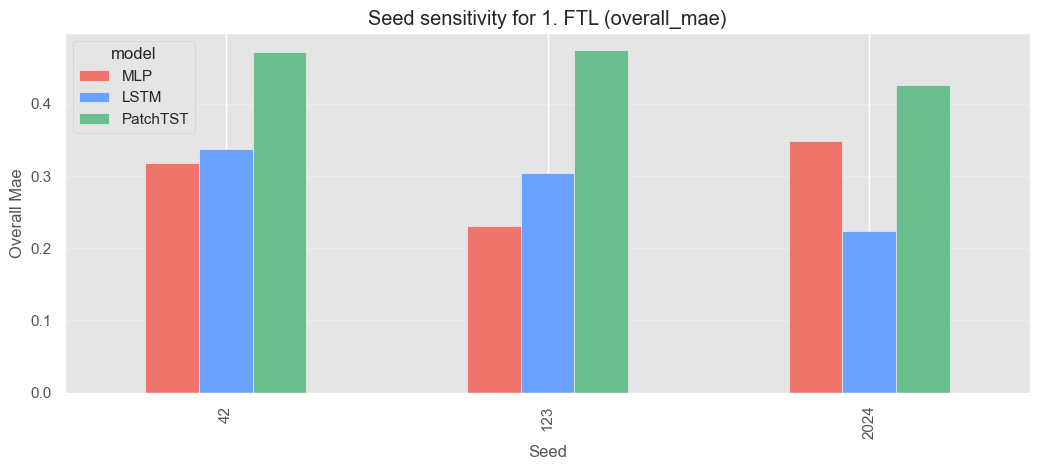

model,seed,MLP,LSTM,PatchTST
0,42,0.318187,0.337549,0.472528
1,123,0.230428,0.304517,0.474016
2,2024,0.348348,0.223464,0.425987


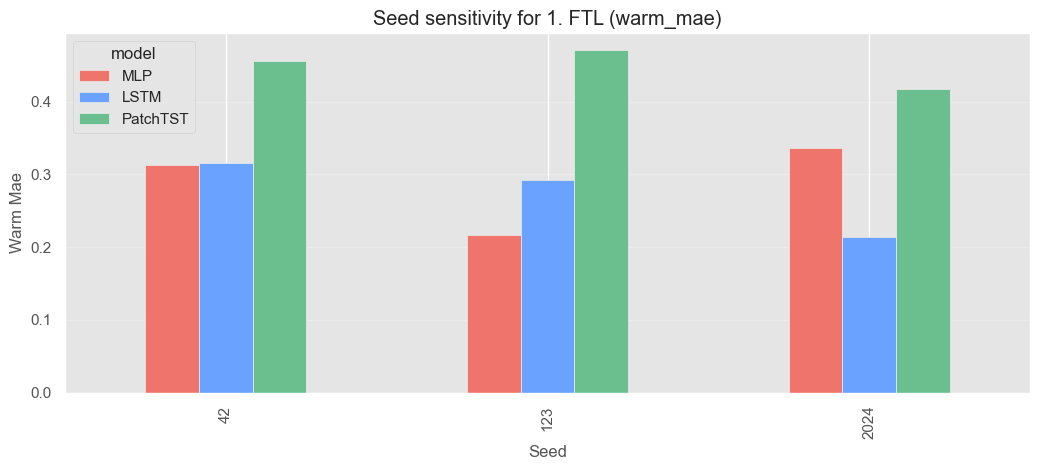

model,seed,MLP,LSTM,PatchTST
0,42,0.312544,0.316038,0.456616
1,123,0.217357,0.292606,0.470685
2,2024,0.336664,0.213984,0.418081


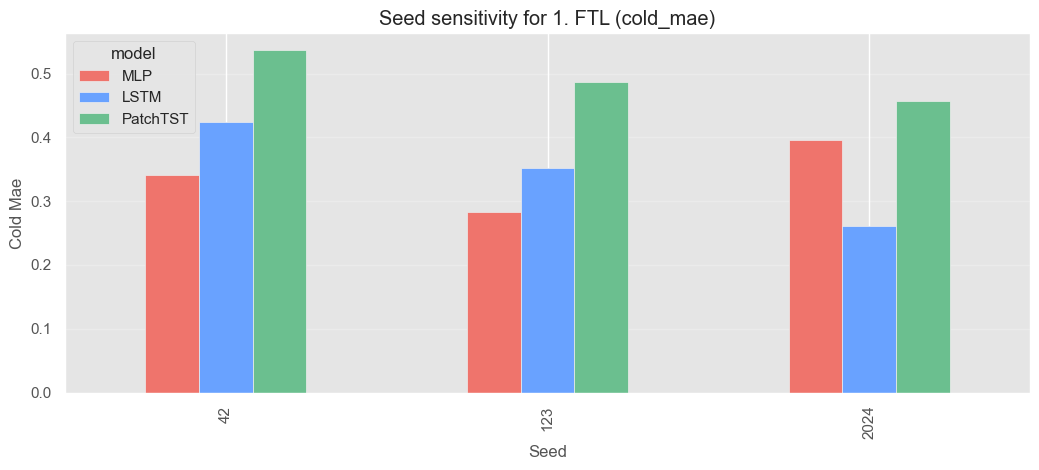

model,seed,MLP,LSTM,PatchTST
0,42,0.340757,0.423593,0.536173
1,123,0.282713,0.352159,0.487338
2,2024,0.395083,0.261382,0.457612


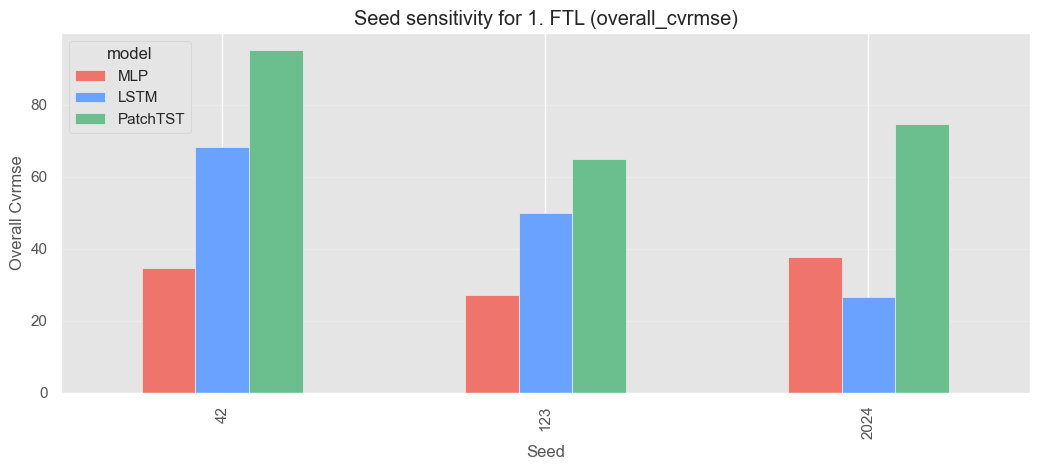

model,seed,MLP,LSTM,PatchTST
0,42,34.639142,68.408852,95.150734
1,123,27.136162,49.796799,64.950577
2,2024,37.646467,26.566648,74.737602


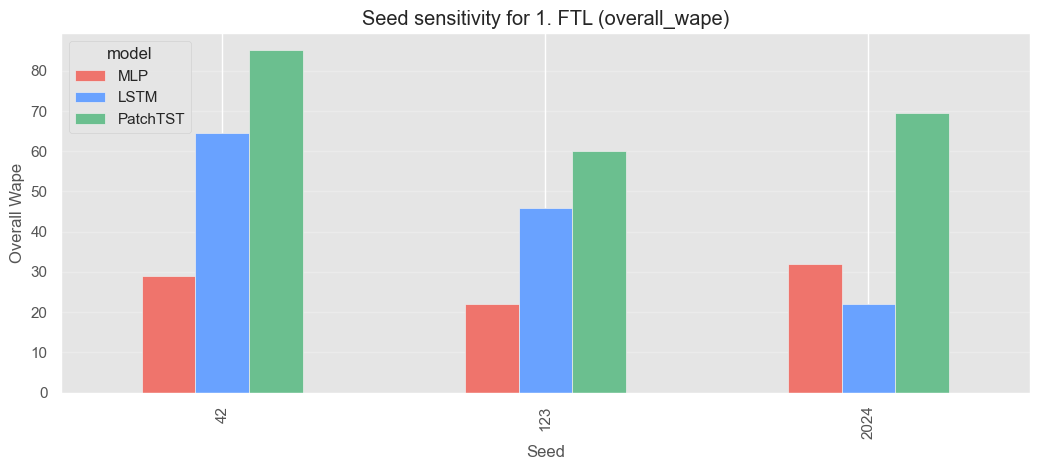

model,seed,MLP,LSTM,PatchTST
0,42,29.053653,64.560204,85.086082
1,123,21.965069,45.853382,59.991093
2,2024,32.043992,21.948486,69.471916


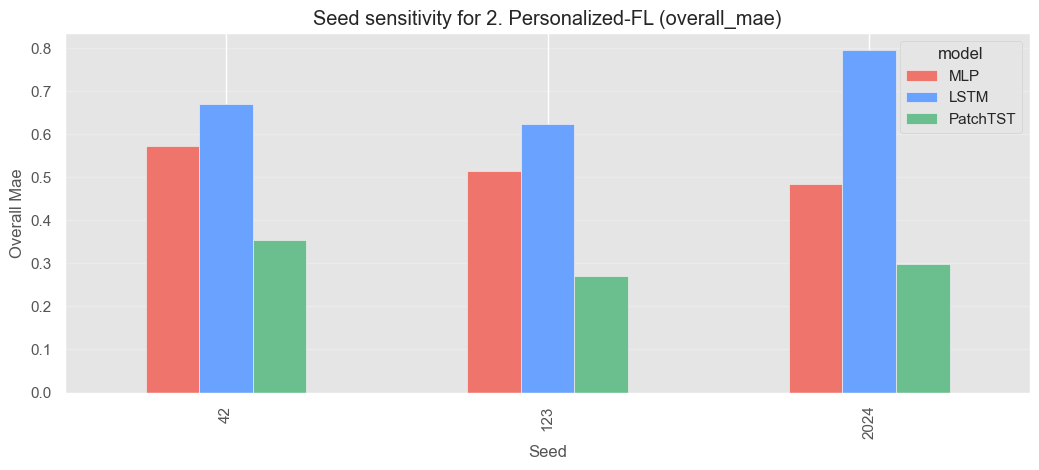

model,seed,MLP,LSTM,PatchTST
0,42,0.572855,0.670397,0.354593
1,123,0.514172,0.624646,0.271121
2,2024,0.484080,0.794621,0.298978


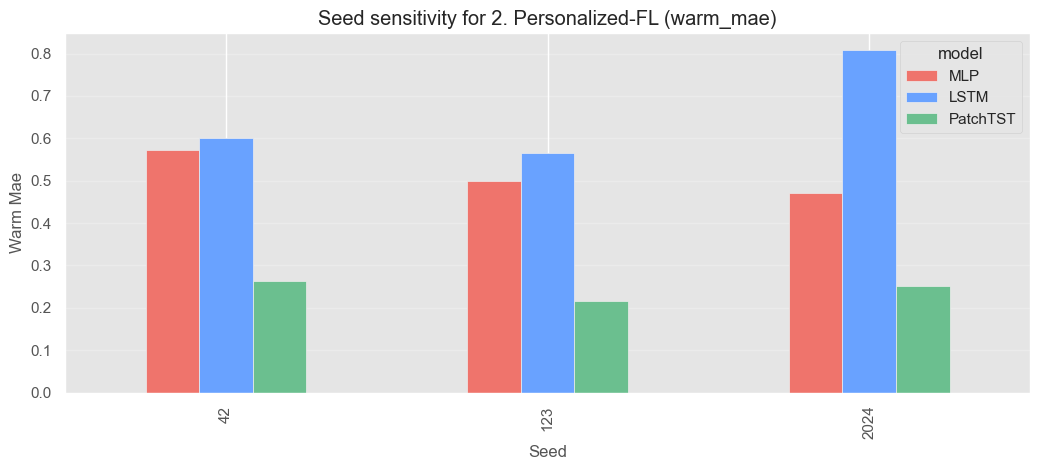

model,seed,MLP,LSTM,PatchTST
0,42,0.572030,0.601822,0.263504
1,123,0.498676,0.565053,0.216071
2,2024,0.471386,0.807416,0.252277


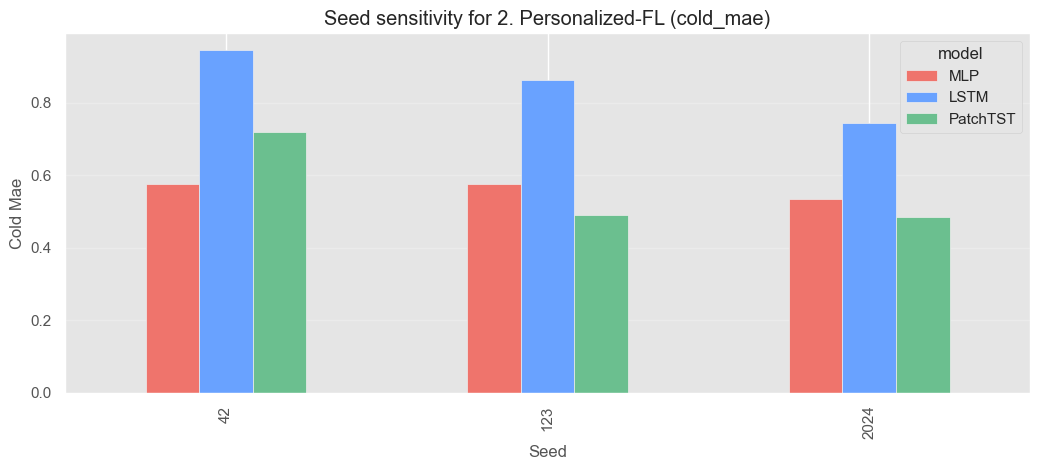

model,seed,MLP,LSTM,PatchTST
0,42,0.576155,0.944699,0.718947
1,123,0.576155,0.863016,0.491321
2,2024,0.534856,0.743442,0.485782


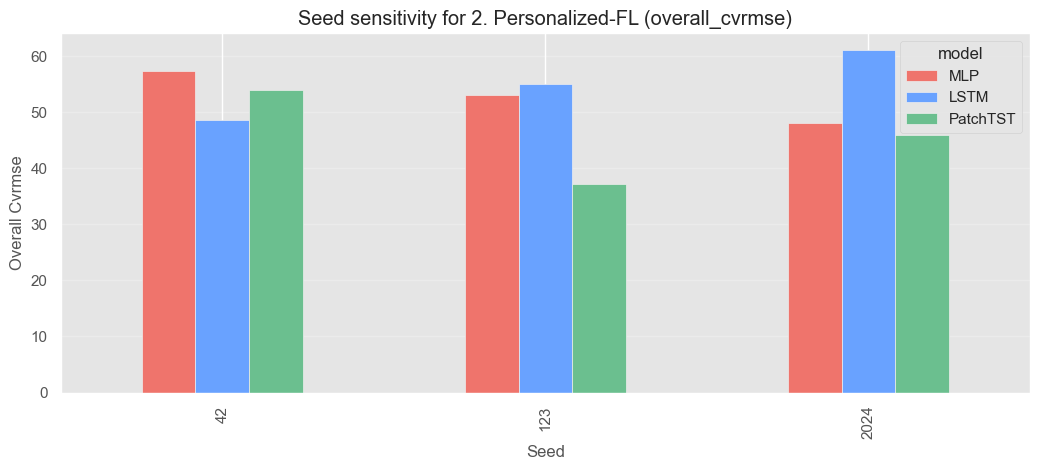

model,seed,MLP,LSTM,PatchTST
0,42,57.425093,48.525902,53.968521
1,123,53.090950,55.110657,37.167217
2,2024,48.086855,61.021839,46.005383


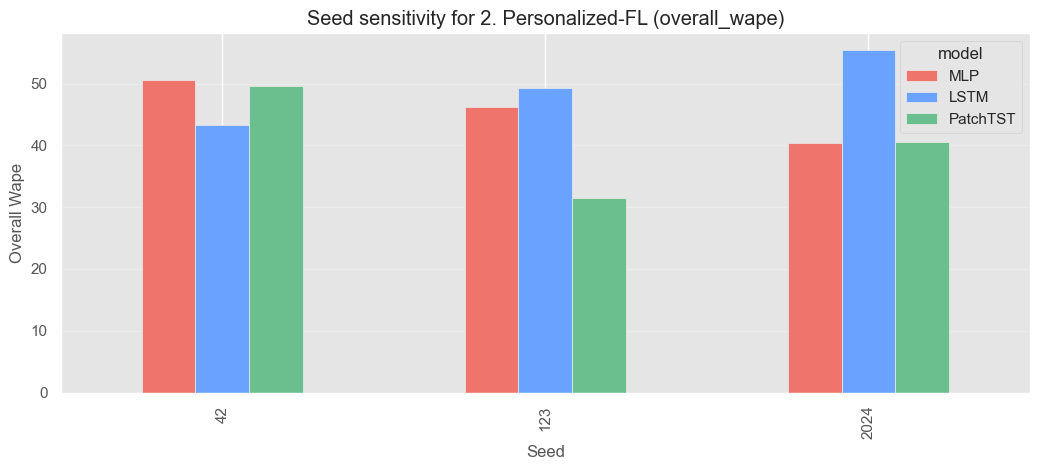

model,seed,MLP,LSTM,PatchTST
0,42,50.526504,43.336353,49.596451
1,123,46.216831,49.259319,31.447008
2,2024,40.477661,55.384220,40.560715


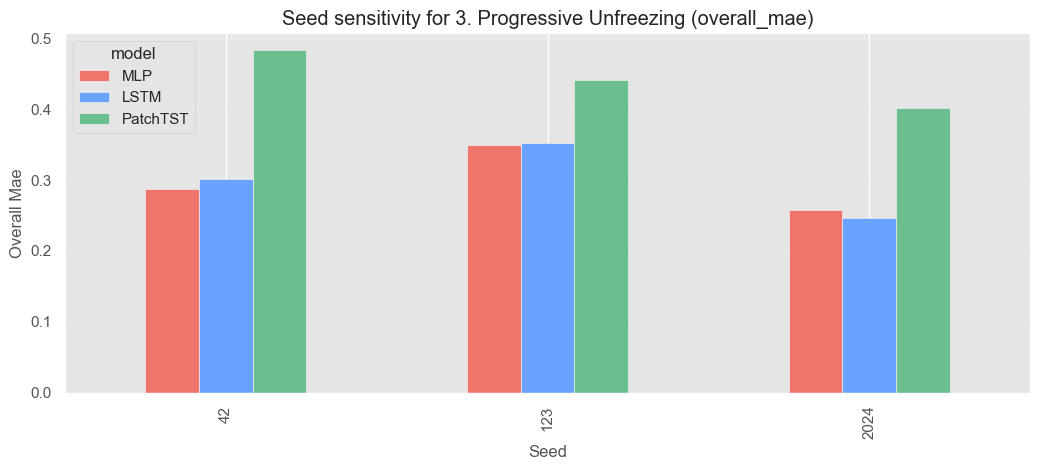

model,seed,MLP,LSTM,PatchTST
0,42,0.287381,0.301755,0.482944
1,123,0.349383,0.352255,0.441284
2,2024,0.257995,0.246869,0.401908


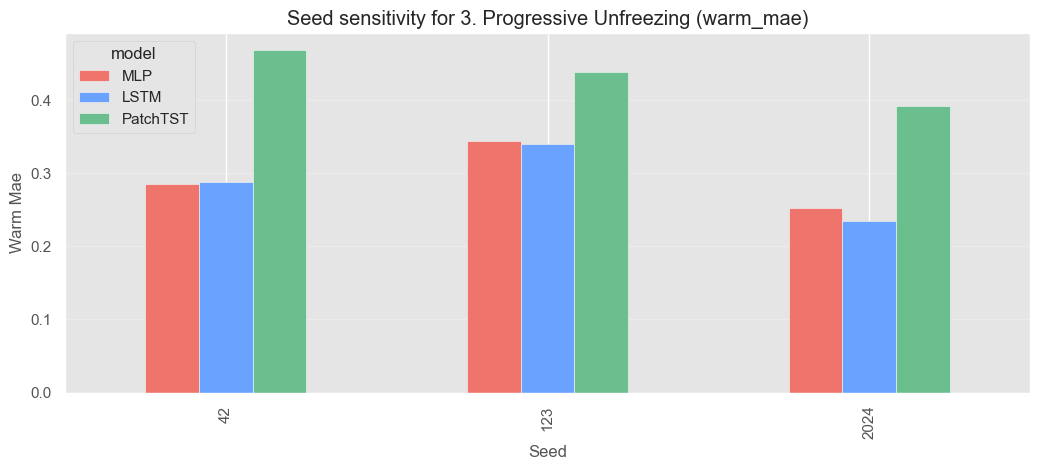

model,seed,MLP,LSTM,PatchTST
0,42,0.285010,0.287711,0.468439
1,123,0.343846,0.340415,0.438590
2,2024,0.252999,0.235218,0.392829


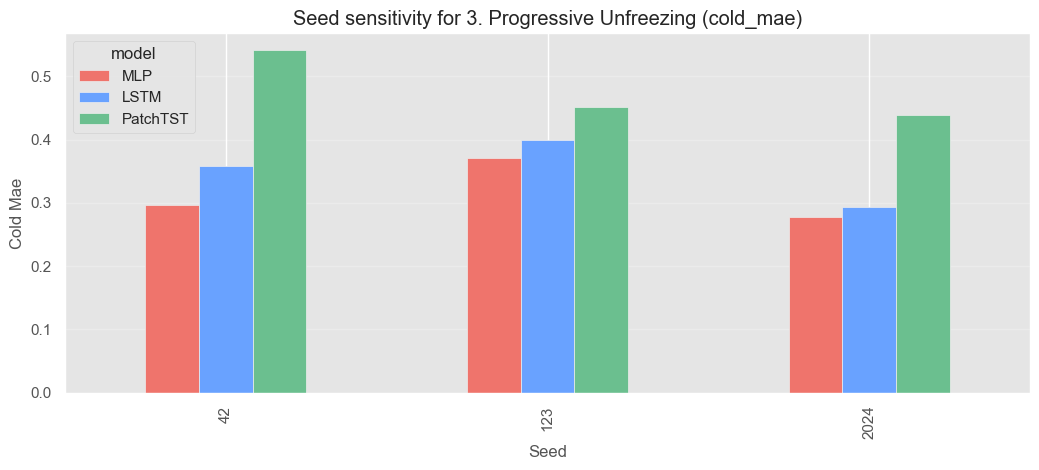

model,seed,MLP,LSTM,PatchTST
0,42,0.296862,0.357928,0.540966
1,123,0.371534,0.399613,0.452059
2,2024,0.277980,0.293475,0.438222


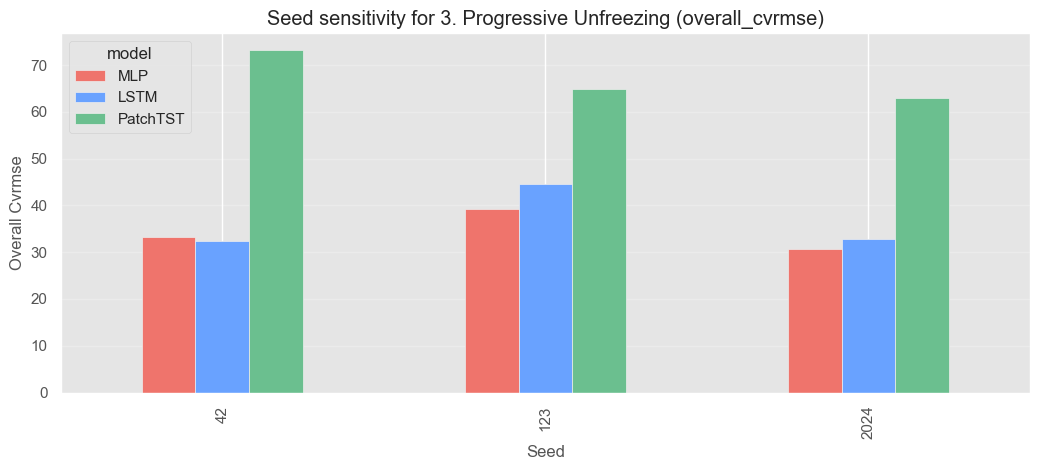

model,seed,MLP,LSTM,PatchTST
0,42,33.281174,32.449451,73.149666
1,123,39.207580,44.640957,64.830109
2,2024,30.647620,32.858231,62.989445


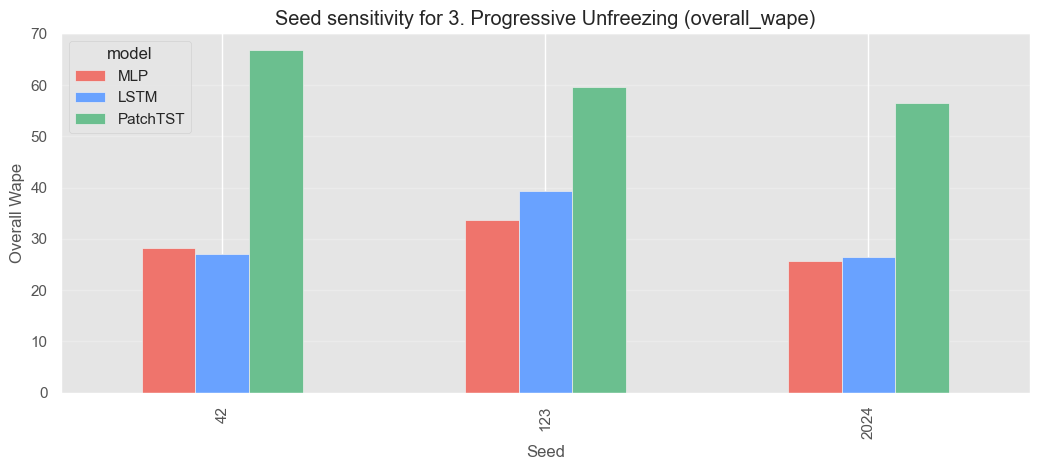

model,seed,MLP,LSTM,PatchTST
0,42,28.177068,27.073854,66.746315
1,123,33.705105,39.280071,59.637272
2,2024,25.685776,26.368555,56.486160


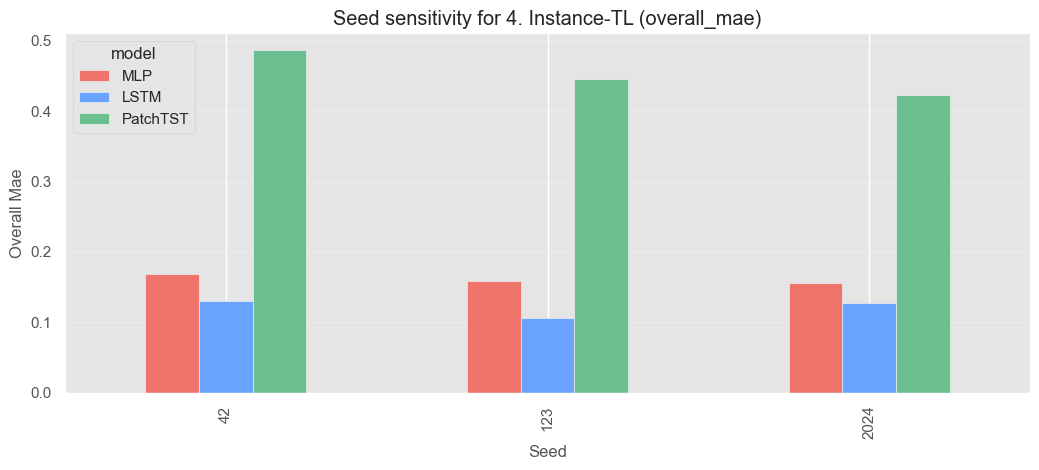

model,seed,MLP,LSTM,PatchTST
0,42,0.169222,0.130628,0.486494
1,123,0.158298,0.105528,0.445232
2,2024,0.155279,0.127835,0.423701


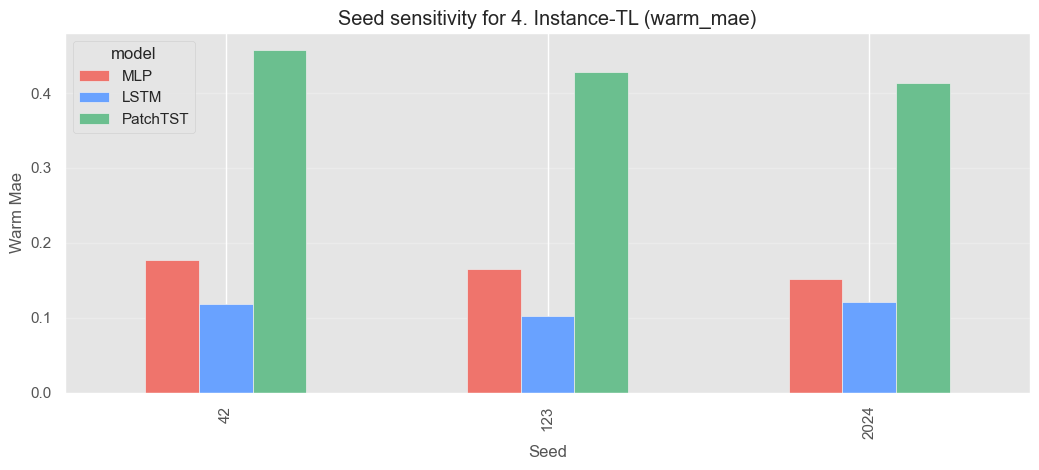

model,seed,MLP,LSTM,PatchTST
0,42,0.176903,0.117789,0.456851
1,123,0.165333,0.101744,0.428403
2,2024,0.151545,0.120376,0.413062


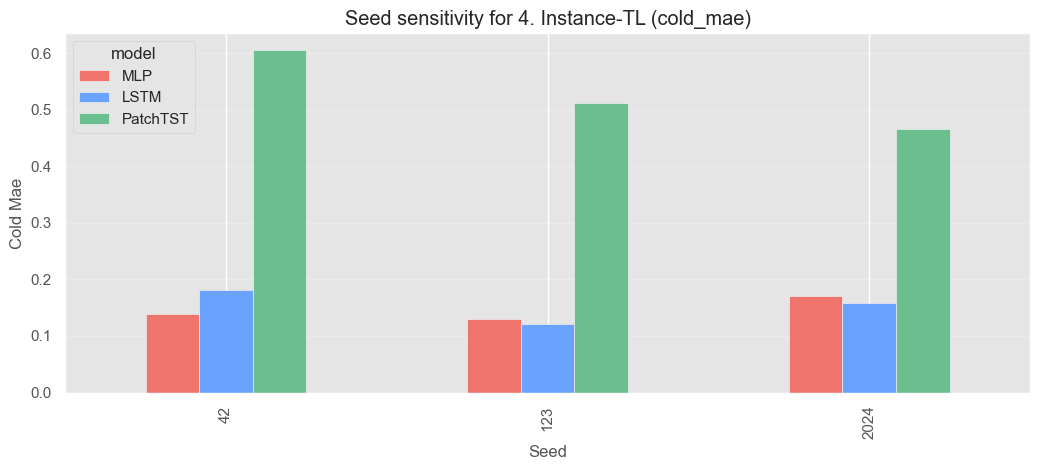

model,seed,MLP,LSTM,PatchTST
0,42,0.138499,0.181981,0.605066
1,123,0.130159,0.120663,0.512548
2,2024,0.170216,0.157671,0.466261


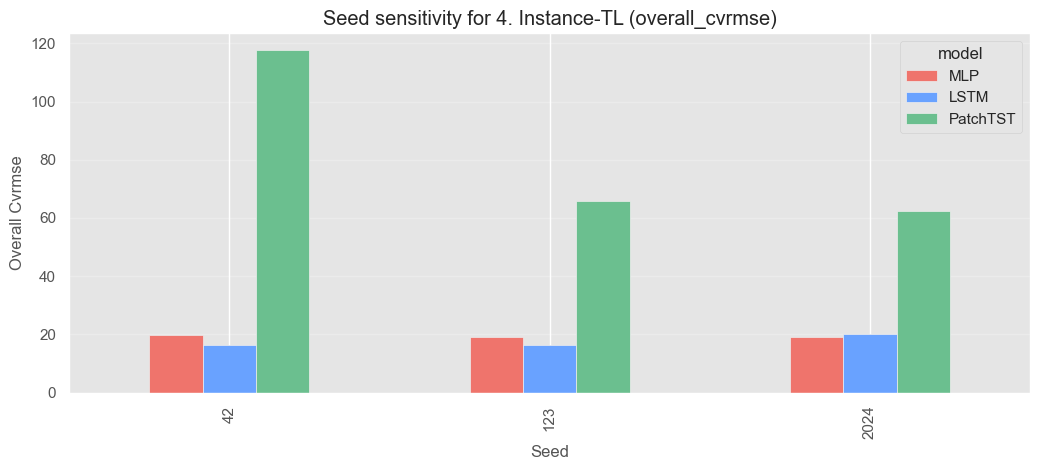

model,seed,MLP,LSTM,PatchTST
0,42,19.676574,16.475052,117.595261
1,123,18.954069,16.285570,65.929420
2,2024,19.032662,20.031261,62.230522


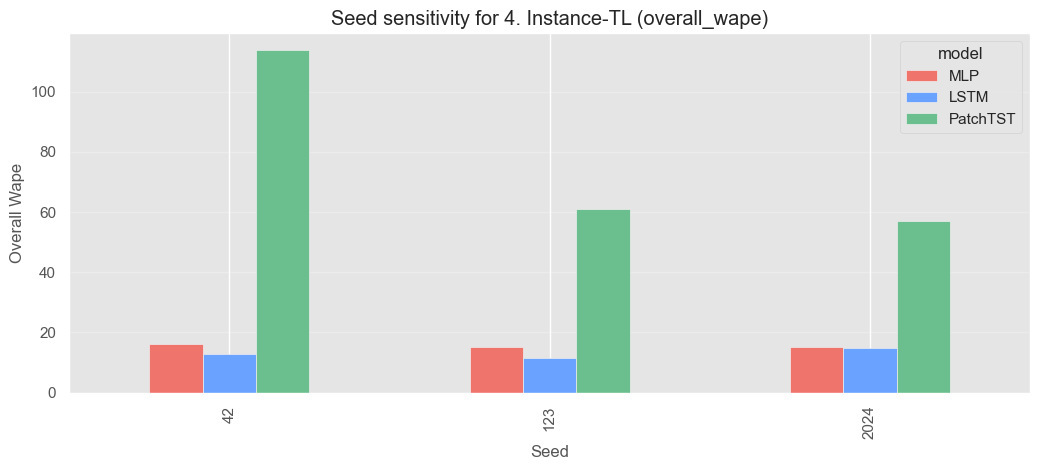

model,seed,MLP,LSTM,PatchTST
0,42,16.018918,12.939449,113.715179
1,123,15.016095,11.394103,61.031422
2,2024,15.075167,14.821021,57.030045


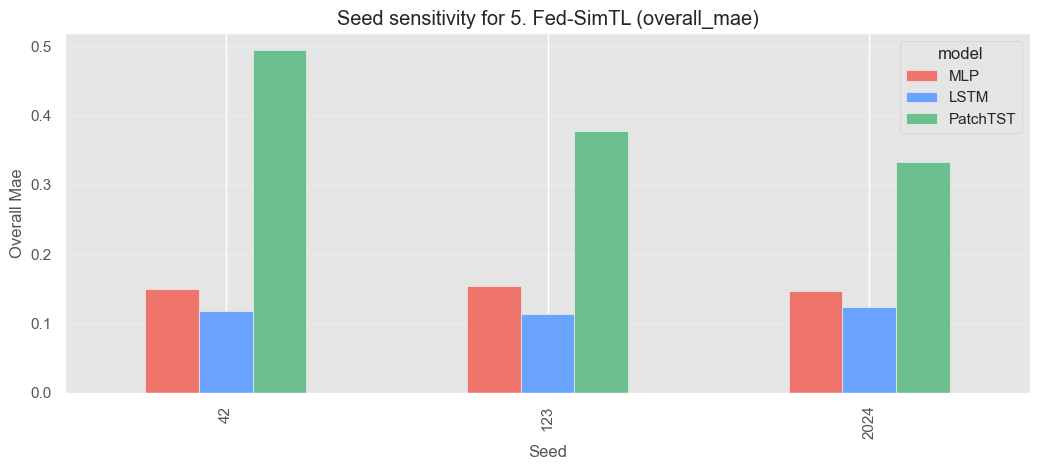

model,seed,MLP,LSTM,PatchTST
0,42,0.150183,0.117393,0.494479
1,123,0.154082,0.113728,0.377739
2,2024,0.146217,0.123873,0.333680


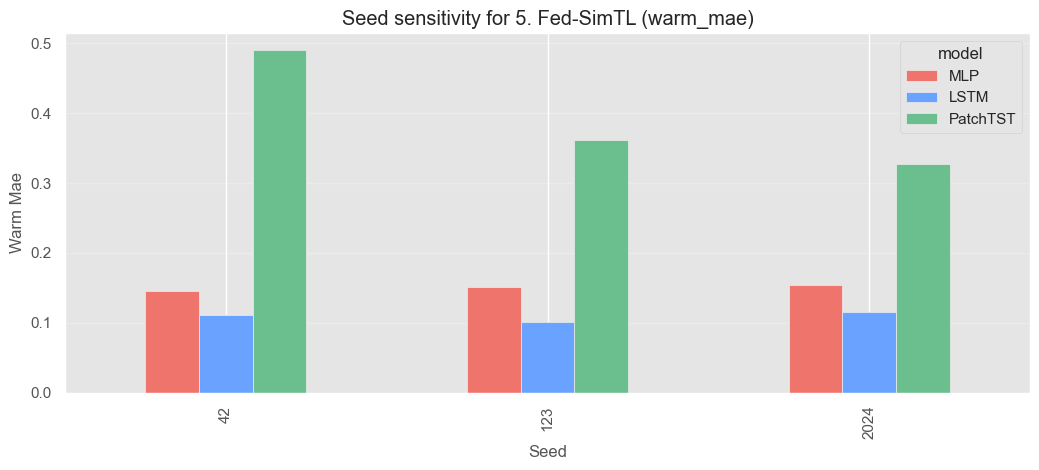

model,seed,MLP,LSTM,PatchTST
0,42,0.145514,0.110654,0.489853
1,123,0.151728,0.101674,0.361397
2,2024,0.154516,0.114802,0.327262


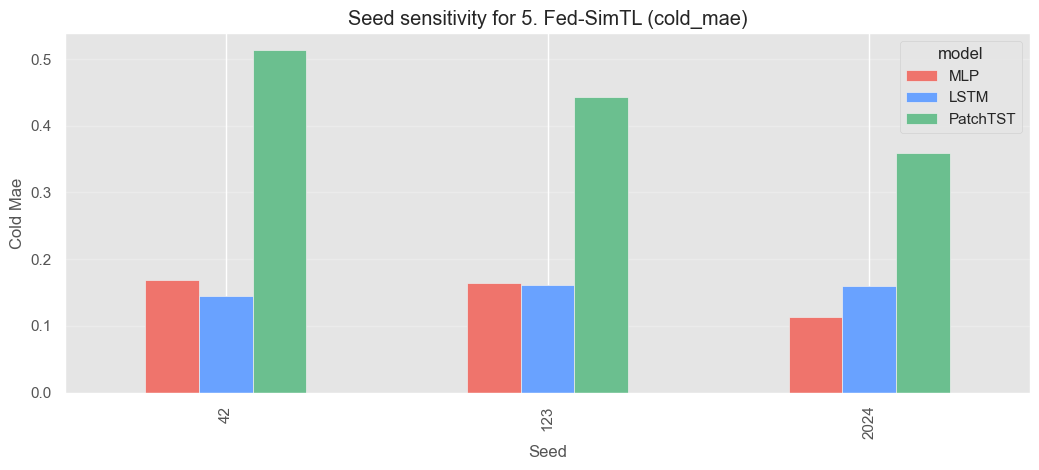

model,seed,MLP,LSTM,PatchTST
0,42,0.168858,0.144346,0.512985
1,123,0.163496,0.161942,0.443106
2,2024,0.113021,0.160160,0.359350


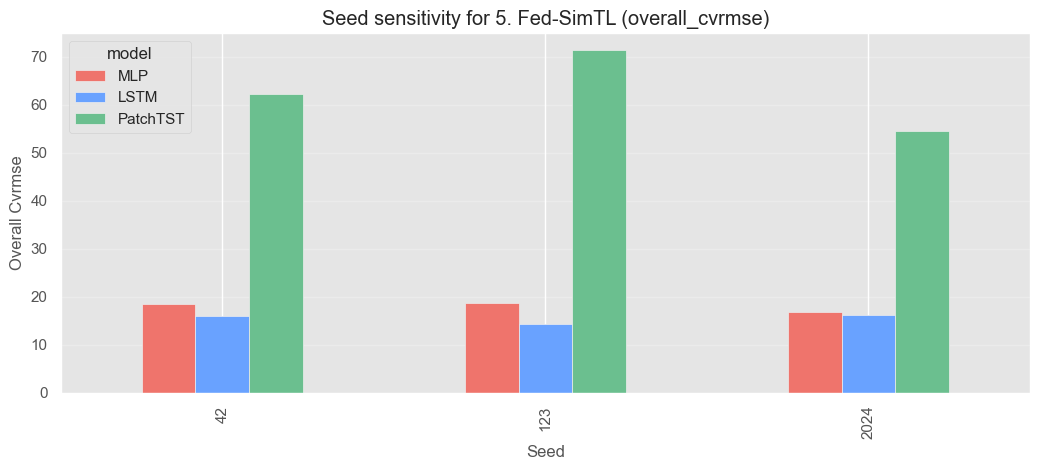

model,seed,MLP,LSTM,PatchTST
0,42,18.412348,15.951449,62.194717
1,123,18.632132,14.312796,71.331665
2,2024,16.800215,16.250704,54.525322


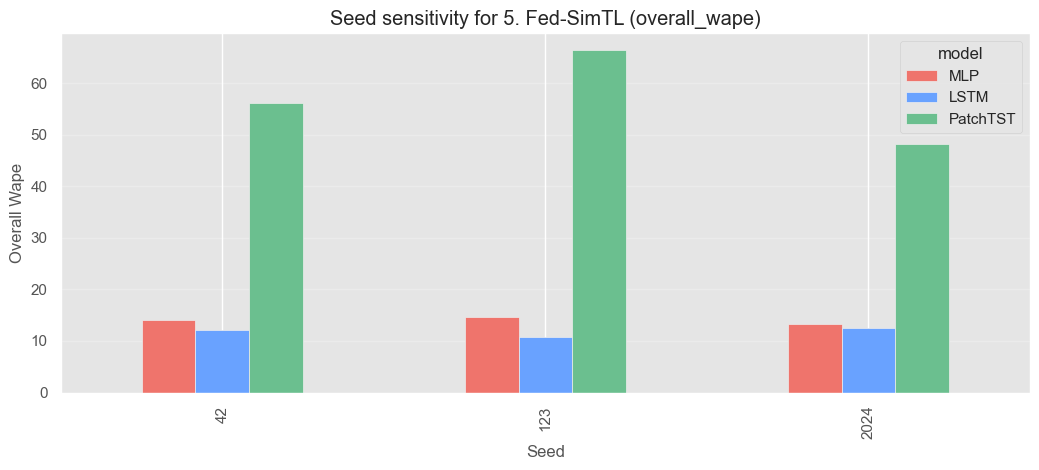

model,seed,MLP,LSTM,PatchTST
0,42,14.158681,12.060270,56.152401
1,123,14.696657,10.798671,66.408485
2,2024,13.271740,12.533324,48.299549


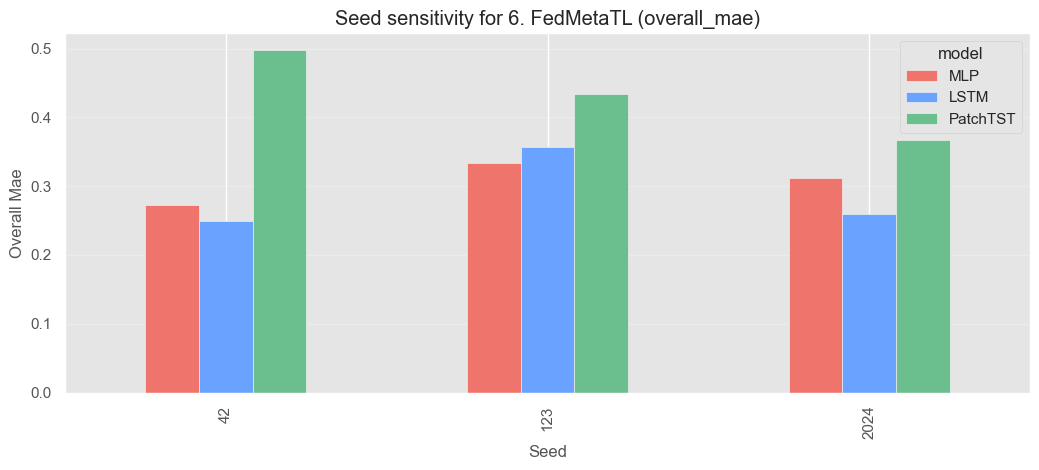

model,seed,MLP,LSTM,PatchTST
0,42,0.272462,0.249723,0.497350
1,123,0.334010,0.356371,0.433367
2,2024,0.312235,0.258813,0.367470


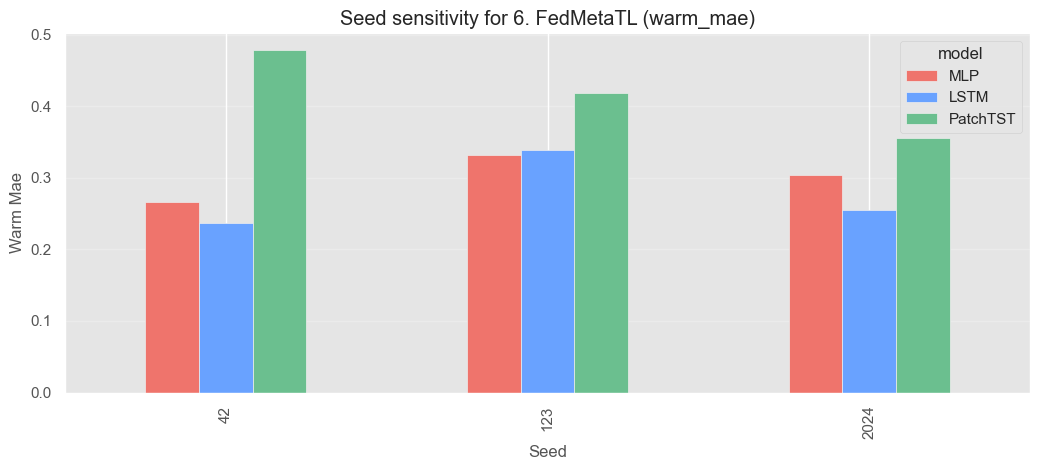

model,seed,MLP,LSTM,PatchTST
0,42,0.266884,0.236948,0.478360
1,123,0.332701,0.338498,0.419442
2,2024,0.304806,0.254592,0.355629


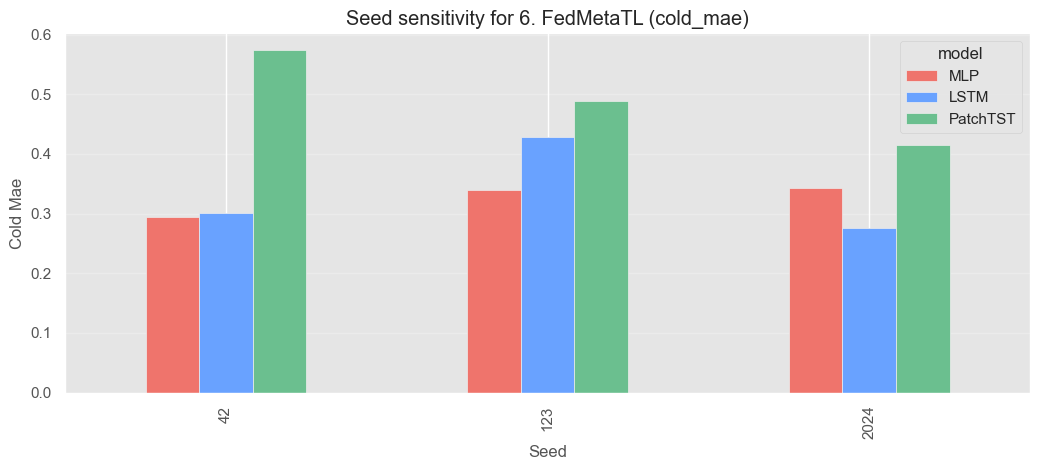

model,seed,MLP,LSTM,PatchTST
0,42,0.294777,0.300822,0.573312
1,123,0.339243,0.427863,0.489064
2,2024,0.341948,0.275694,0.414831


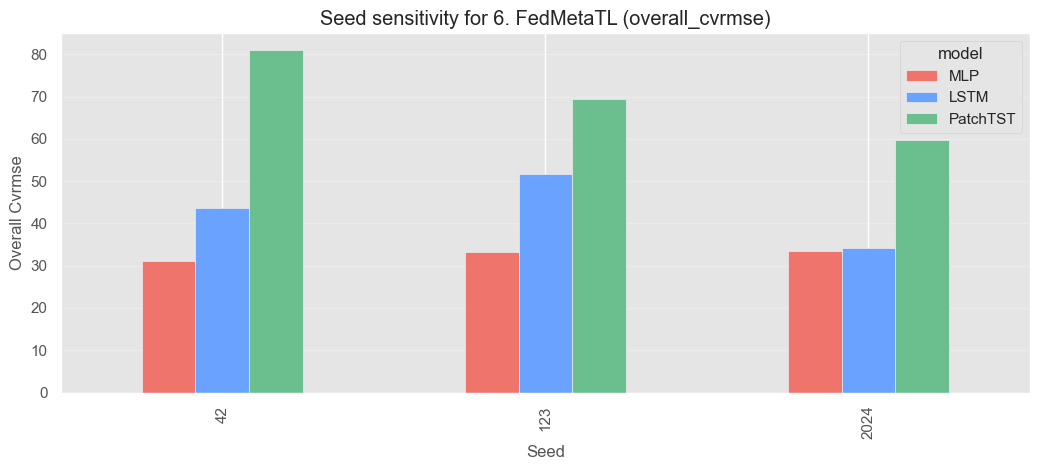

model,seed,MLP,LSTM,PatchTST
0,42,31.062429,43.691177,80.951653
1,123,33.247933,51.634724,69.513618
2,2024,33.415516,34.301273,59.688145


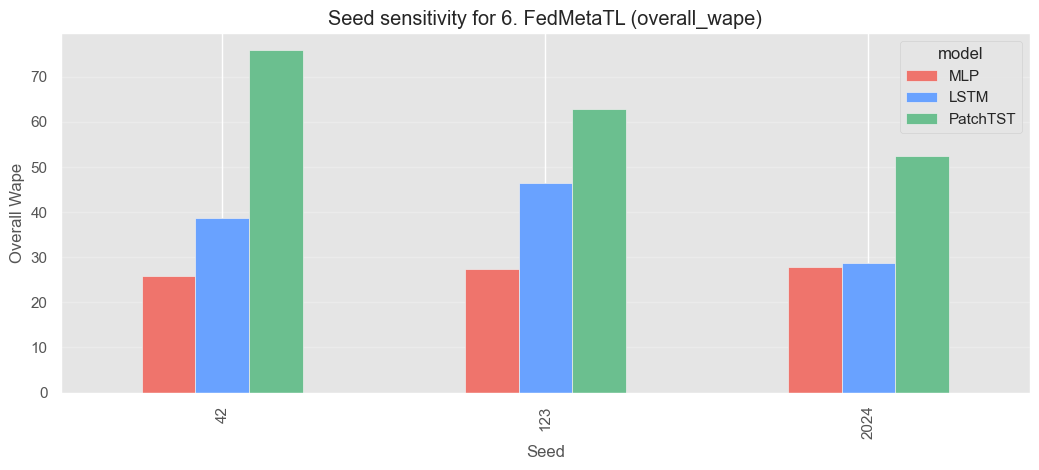

model,seed,MLP,LSTM,PatchTST
0,42,25.831858,38.766674,75.850014
1,123,27.279778,46.392658,62.921806
2,2024,27.866697,28.612211,52.472401


In [34]:
# Seed sensitivity plots for all strategies and all metrics

for strategy in DISPLAY_STRATEGIES:

    for metric in METRICS:

        d = all_seed_results[
            all_seed_results['strategy'] == strategy
        ].copy()

        if d.empty:
            print(f'No rows for strategy: {strategy}')
            continue

        d = d[d['seed'].isin(SEEDS)].sort_values(['seed', 'model'])

        pivot = d.pivot_table(
            index='seed',
            columns='model',
            values=metric,
            aggfunc='mean'
        )

        preferred_order = ['MLP', 'LSTM', 'PatchTST']

        existing_cols = [c for c in preferred_order if c in pivot.columns]
        pivot = pivot[existing_cols]

        pivot.plot(
            kind='bar',
            figsize=(10.5, 4.8),
            color=['#ef746c', '#69a2ff', '#6bbf8f'][:len(existing_cols)]
        )

        plt.title(
            f'Seed sensitivity for {strategy} ({metric})'
        )

        plt.xlabel('Seed')

        plt.ylabel(
            metric.replace('_', ' ').title()
        )

        plt.grid(axis='y', alpha=0.25)

        plt.tight_layout()
        plt.show()

        display(pivot.reset_index())

## How To Run
1. In each model notebook, set `SEED` (e.g. `SEED=42`), run training/evaluation, then run the final standardized export cell.
2. Repeat for all seeds in `SEEDS`.
3. Run this notebook to aggregate and plot.


In [35]:
# Ablation table: FTL vs key variants (seed-aware)
import numpy as np
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("saved_results")
RESULTS_DIR.mkdir(exist_ok=True)

MODEL_ORDER = ["MLP", "LSTM", "PatchTST"]
COMPARISONS = [
    ("FTL vs No Pretraining", "1b. FedAvg (No Pretrain)"),
    ("FTL vs Personalized-FL", "2. Personalized-FL"),
    ("FTL vs FedMetaTL", "6. FedMetaTL"),
    ("FTL vs Progressive Unfreezing", "3. Progressive Unfreezing"),
]

def _norm_model(m):
    s = str(m).upper()
    if s == "PATCHTST":
        return "PatchTST"
    if s == "LSTM":
        return "LSTM"
    if s == "MLP":
        return "MLP"
    return str(m)

df = all_seed_results.copy()
df["model"] = df["model"].map(_norm_model)
df["seed"] = df["seed"].astype(int)

rows = []
for model in MODEL_ORDER:
    dm = df[df["model"] == model].copy()
    if dm.empty:
        continue

    ftl = dm[dm["strategy"] == "1. FTL"][["seed", "cold_mae"]].rename(columns={"cold_mae": "ftl_cold"})
    if ftl.empty:
        continue

    for label, comp_strategy in COMPARISONS:
        comp = dm[dm["strategy"] == comp_strategy][["seed", "cold_mae"]].rename(columns={"cold_mae": "comp_cold"})
        if comp.empty:
            continue

        merged = pd.merge(ftl, comp, on="seed", how="inner")
        if merged.empty:
            continue

        seeds_used = sorted(merged["seed"].unique().tolist())
        ftl_mean = float(merged["ftl_cold"].mean())
        comp_mean = float(merged["comp_cold"].mean())

        if comp_mean == 0:
            rel_txt = "N/A"
        else:
            rel_pct = abs(ftl_mean - comp_mean) / abs(comp_mean) * 100.0
            rel_txt = f"{rel_pct:.1f}% {'lower' if ftl_mean < comp_mean else 'higher'}"

        rows.append({
            "Model": model,
            "Seeds": ", ".join(str(s) for s in seeds_used),
            "Comparison": label,
            "FTL Cold MAE": round(ftl_mean, 3),
            "Comparator Cold MAE": round(comp_mean, 3),
            "Relative Change of FTL": rel_txt,
        })

ablation_df = pd.DataFrame(rows)
ablation_df["Model"] = pd.Categorical(ablation_df["Model"], categories=MODEL_ORDER, ordered=True)
ablation_df = ablation_df.sort_values(["Model", "Comparison"]).reset_index(drop=True)
ablation_df["Model"] = ablation_df["Model"].astype(str)

display(ablation_df)

csv_path = RESULTS_DIR / "ablation_ftl_vs_variants.csv"
tex_path = RESULTS_DIR / "ablation_ftl_vs_variants.tex"

ablation_df.to_csv(csv_path, index=False)

latex_df = ablation_df.copy()
with open(tex_path, "w", encoding="utf-8") as f:
    f.write("\\begin{table}[htbp]\n\\centering\n")
    f.write("\\caption{Ablation: FTL compared with related variants (Cold MAE, mean over shared seeds).}\n")
    f.write("\\label{tab:ablation_ftl_variants}\n")
    f.write("\\begin{tabular}{lllccc}\n\\hline\n")
    f.write("Model & Seeds & Comparison & FTL Cold MAE & Comparator Cold MAE & Relative Change of FTL \\\\ \\hline\n")
    for _, r in latex_df.iterrows():
        f.write(f"{r['Model']} & {r['Seeds']} & {r['Comparison']} & {r['FTL Cold MAE']:.3f} & {r['Comparator Cold MAE']:.3f} & {r['Relative Change of FTL']} \\\\\n")
    f.write("\\hline\n\\end{tabular}\n\\end{table}\n")

print("Saved:", csv_path)
print("Saved:", tex_path)

,Model,Seeds,Comparison,FTL Cold MAE,Comparator Cold MAE,Relative Change of FTL
0,MLP,"42, 123, 2024",FTL vs FedMetaTL,0.340,0.325,4.4% higher
1,MLP,"42, 123, 2024",FTL vs No Pretraining,0.340,0.393,13.6% lower
2,MLP,"42, 123, 2024",FTL vs Personalized-FL,0.340,0.562,39.6% lower
3,MLP,"42, 123, 2024",FTL vs Progressive Unfreezing,0.340,0.315,7.6% higher
4,LSTM,"42, 123, 2024",FTL vs FedMetaTL,0.346,0.335,3.3% higher
5,LSTM,"42, 123, 2024",FTL vs No Pretraining,0.346,0.602,42.5% lower
6,LSTM,"42, 123, 2024",FTL vs Personalized-FL,0.346,0.850,59.3% lower
7,LSTM,"42, 123, 2024",FTL vs Progressive Unfreezing,0.346,0.350,1.3% lower
8,PatchTST,"42, 123, 2024",FTL vs FedMetaTL,0.494,0.492,0.3% higher
9,PatchTST,"42, 123, 2024",FTL vs No Pretraining,0.494,0.864,42.9% lower


Saved: saved_results\ablation_ftl_vs_variants.csv
Saved: saved_results\ablation_ftl_vs_variants.tex


Saved figure: saved_results\lstm_all6_mae_log1p_boxplot_overall_warm_cold.png
Saved source data: saved_results\lstm_all6_mae_log1p_boxplot_source.csv


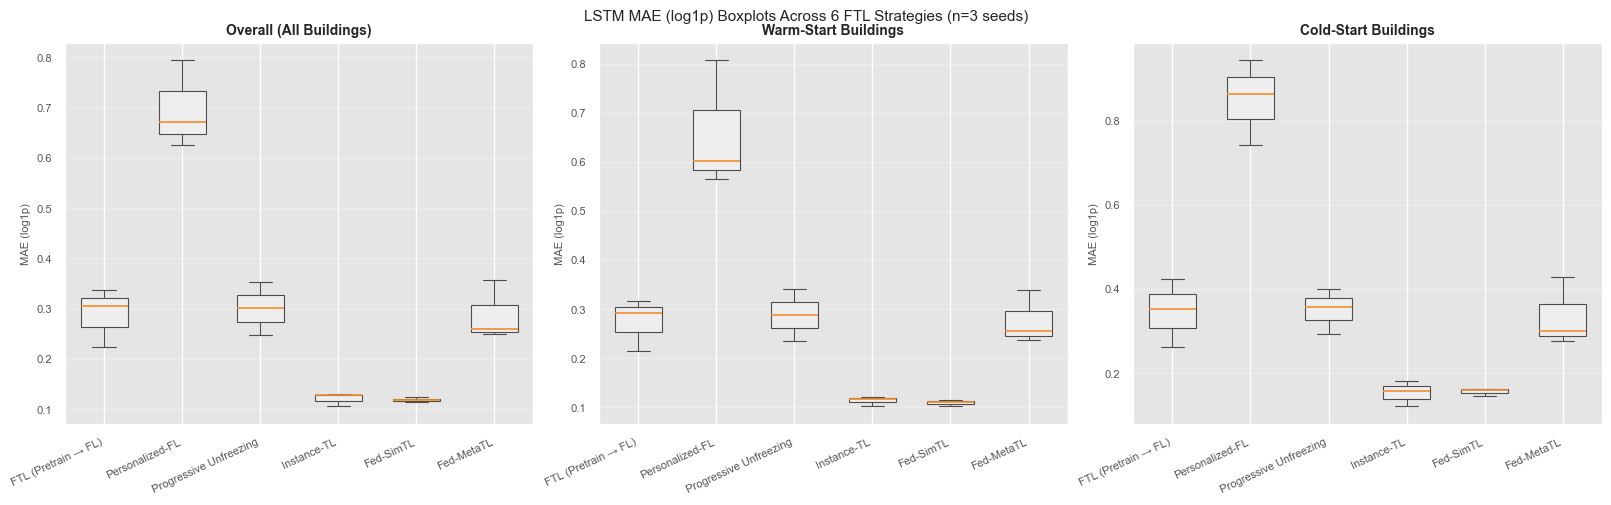

In [36]:
# One figure: A (MLP), B (LSTM), C (PatchTST)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [42, 123, 2024]
SUMMARY_DIR = Path('saved_results')
OUT_FIG = SUMMARY_DIR / 'ABC_mlp_lstm_patchtst_mae_log1p_boxplot_overall.png'
OUT_CSV = SUMMARY_DIR / 'ABC_mlp_lstm_patchtst_mae_log1p_boxplot_overall_source.csv'

STRATEGY_MAP = {
    '1. FTL': 'FTL (Pretrain -> FL)',
    '2. Personalized-FL': 'Personalized-FL',
    '3. Progressive Unfreezing': 'Progressive Unfreezing',
    '4. Instance-TL': 'Instance-TL',
    '5. Fed-SimTL': 'Fed-SimTL',
    '6. FedMetaTL': 'Fed-MetaTL',
}
ORDER_RAW = list(STRATEGY_MAP.keys())
ORDER = [STRATEGY_MAP[k] for k in ORDER_RAW]

MODELS = [
    ('A', 'mlp', 'MLP'),
    ('B', 'lstm', 'LSTM'),
    ('C', 'patchtst', 'PatchTST'),
]

all_rows = []
for label, model_key, model_name in MODELS:
    rows = []
    for seed in SEEDS:
        f = SUMMARY_DIR / f'{model_key}_seed_{seed}_summary.csv'
        if not f.exists():
            print(f'Skipping missing file: {f}')
            continue
        d = pd.read_csv(f)
        d['strategy'] = d['strategy'].astype(str).str.strip()
        d = d[d['strategy'].isin(ORDER_RAW)].copy()
        d['strategy_display'] = d['strategy'].map(STRATEGY_MAP)
        d['seed'] = seed
        d['model'] = model_name
        d['panel'] = label
        rows.append(d[['panel', 'model', 'seed', 'strategy_display', 'overall_mae']])

    if not rows:
        raise RuntimeError(f'No {model_name} summary rows found for requested seeds/strategies.')

    all_rows.append(pd.concat(rows, ignore_index=True))

plot_df = pd.concat(all_rows, ignore_index=True)
plot_df = plot_df.rename(columns={'overall_mae': 'mae_log1p'})
plot_df.to_csv(OUT_CSV, index=False)

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, (label, model_key, model_name) in zip(axes, MODELS):
    sub = plot_df[plot_df['model'] == model_name].copy()
    grouped = [sub.loc[sub['strategy_display'] == s, 'mae_log1p'].dropna().values for s in ORDER]

    ax.boxplot(
        grouped,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        medianprops=dict(color='#f28e2b', linewidth=1.2),
        boxprops=dict(facecolor='#eeeeee', edgecolor='#4d4d4d', linewidth=0.8),
        whiskerprops=dict(color='#4d4d4d', linewidth=0.8),
        capprops=dict(color='#4d4d4d', linewidth=0.8),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='#7f7f7f', markeredgecolor='#7f7f7f', alpha=0.6),
    )

    ax.set_title(f'{label}: {model_name}', fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, len(ORDER) + 1))
    ax.set_xticklabels(ORDER, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('MAE (log1p)', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='y', linestyle='-', alpha=0.3)

fig.suptitle('One Figure: MAE (log1p) Boxplots Across 6 FTL Strategies (All Seeds)', fontsize=12, y=1.03)
fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()
\n

Saved figure: saved_results\lstm_pretraining_volume_vs_coldstart_all_seeds.png
Saved source data: saved_results\lstm_pretraining_volume_vs_coldstart_all_seeds_source.csv


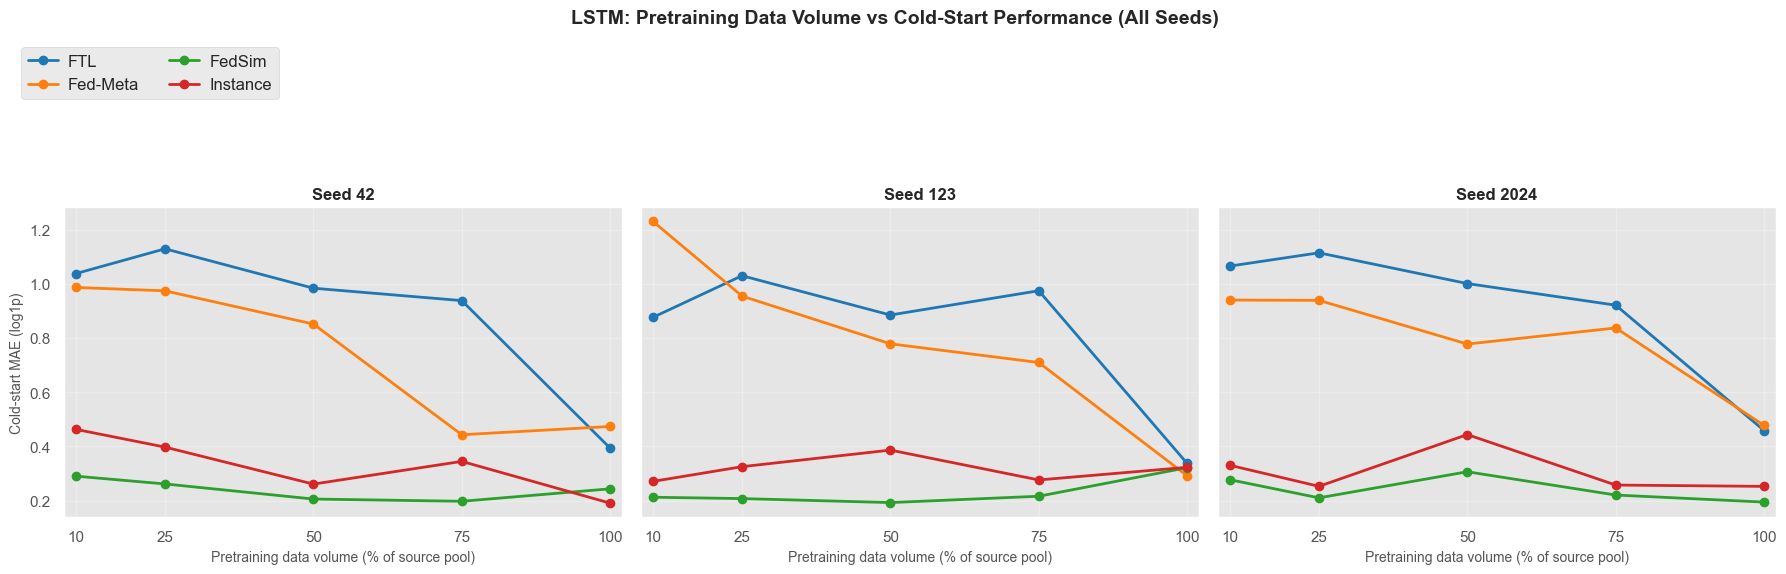

In [41]:
# LSTM: Pretraining Data Volume vs Cold-Start Performance (all seeds)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [42, 123, 2024]
RESULTS_DIR = Path('saved_results')
OUT_FIG = RESULTS_DIR / 'lstm_pretraining_volume_vs_coldstart_all_seeds.png'
OUT_CSV = RESULTS_DIR / 'lstm_pretraining_volume_vs_coldstart_all_seeds_source.csv'

# Keep the four pretraining-sensitive strategies used in the paper plot
STRATEGIES = ['FTL', 'Fed-MetaTL', 'FedSimTL', 'Instance-basedTL']
LABEL_MAP = {
    'FTL': 'FTL',
    'Fed-MetaTL': 'Fed-Meta',
    'FedSimTL': 'FedSim',
    'Instance-basedTL': 'Instance',
}
COLOR_MAP = {
    'FTL': '#1f77b4',
    'Fed-MetaTL': '#ff7f0e',
    'FedSimTL': '#2ca02c',
    'Instance-basedTL': '#d62728',
}

rows = []
for seed in SEEDS:
    f = RESULTS_DIR / f'lstm_pretrain_sweep_all_seed{seed}.csv'
    if not f.exists():
        print(f'Skipping missing file: {f}')
        continue
    d = pd.read_csv(f)
    d['strategy'] = d['strategy'].astype(str).str.strip()
    d = d[d['strategy'].isin(STRATEGIES)].copy()
    d['seed'] = seed
    rows.append(d)

if not rows:
    raise RuntimeError('No LSTM pretraining sweep files found for requested seeds.')

plot_df = pd.concat(rows, ignore_index=True)
plot_df.to_csv(OUT_CSV, index=False)

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, seed in zip(axes, SEEDS):
    sub = plot_df[plot_df['seed'] == seed].copy()
    for strategy in STRATEGIES:
        ds = sub[sub['strategy'] == strategy].sort_values('pretrain_rows')
        if ds.empty:
            continue
        ax.plot(
            ds['pretrain_frac'] * 100,
            ds['cold_mae'],
            marker='o',
            linewidth=2,
            markersize=6,
            label=LABEL_MAP[strategy],
            color=COLOR_MAP[strategy],
        )

    ax.set_title(f'Seed {seed}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pretraining data volume (% of source pool)', fontsize=10)
    ax.set_xlim(8, 102)
    ax.set_xticks([10, 25, 50, 75, 100])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Cold-start MAE (log1p)', fontsize=10)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left', ncol=2, frameon=True, bbox_to_anchor=(0.01, 1.08), fontsize=12, handlelength=1.8, handletextpad=0.6, columnspacing=1.8, borderpad=0.4)
fig.suptitle('LSTM: Pretraining Data Volume vs Cold-Start Performance (All Seeds)', fontsize=14, fontweight='bold', y=1.14)

fig.tight_layout(rect=[0, 0, 1, 0.88])
fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()







Saved figure: saved_results\mlp_all6_mae_log1p_boxplot_overall_warm_cold.png
Saved source data: saved_results\mlp_all6_mae_log1p_boxplot_source.csv


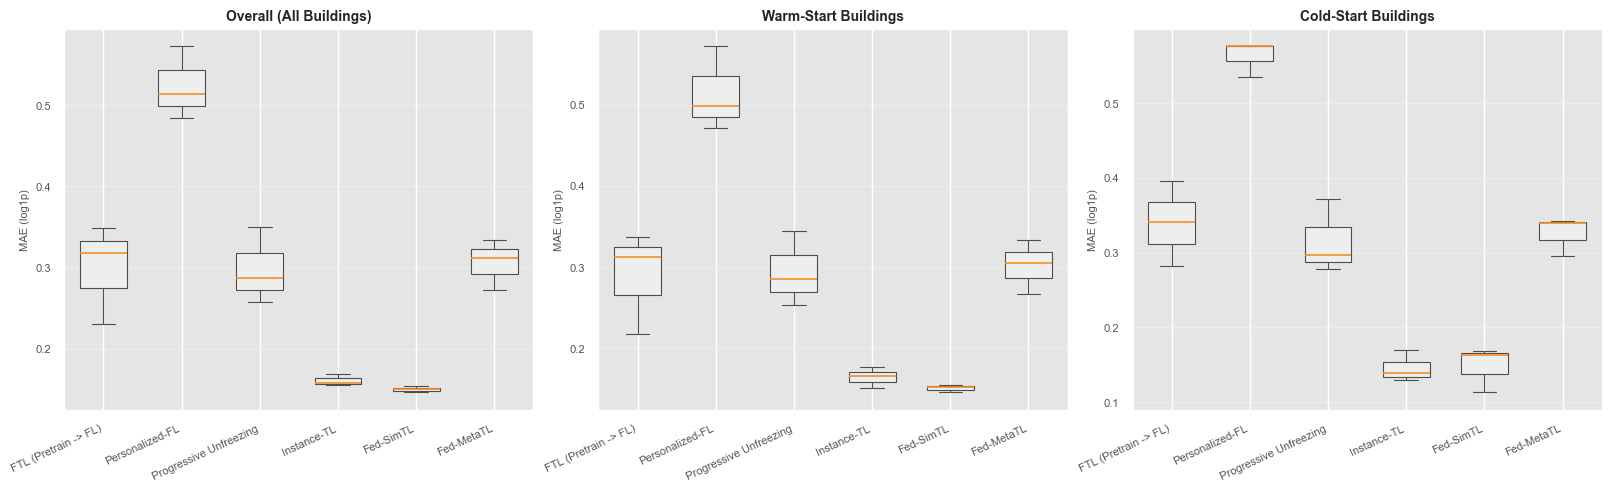

In [38]:
# A: Boxplot comparison of MAE (log1p) across six FTL strategies (all seeds) [MLP]
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [42, 123, 2024]
SUMMARY_DIR = Path('saved_results')
OUT_FIG = SUMMARY_DIR / 'mlp_all6_mae_log1p_boxplot_overall_warm_cold.png'
OUT_CSV = SUMMARY_DIR / 'mlp_all6_mae_log1p_boxplot_source.csv'

STRATEGY_MAP = {
    '1. FTL': 'FTL (Pretrain -> FL)',
    '2. Personalized-FL': 'Personalized-FL',
    '3. Progressive Unfreezing': 'Progressive Unfreezing',
    '4. Instance-TL': 'Instance-TL',
    '5. Fed-SimTL': 'Fed-SimTL',
    '6. FedMetaTL': 'Fed-MetaTL',
}
ORDER_RAW = list(STRATEGY_MAP.keys())
ORDER = [STRATEGY_MAP[k] for k in ORDER_RAW]

rows = []
for seed in SEEDS:
    f = SUMMARY_DIR / f'mlp_seed_{seed}_summary.csv'
    if not f.exists():
        print(f'Skipping missing file: {f}')
        continue
    d = pd.read_csv(f)
    d['strategy'] = d['strategy'].astype(str).str.strip()
    d = d[d['strategy'].isin(ORDER_RAW)].copy()
    d['strategy_display'] = d['strategy'].map(STRATEGY_MAP)
    d['seed'] = seed
    rows.append(d[['seed', 'strategy_display', 'overall_mae', 'warm_mae', 'cold_mae']])

if not rows:
    raise RuntimeError('No MLP summary rows found for requested seeds/strategies.')

plot_df = pd.concat(rows, ignore_index=True)
long_df = plot_df.melt(
    id_vars=['seed', 'strategy_display'],
    value_vars=['overall_mae', 'warm_mae', 'cold_mae'],
    var_name='split',
    value_name='mae_log1p',
)
long_df.to_csv(OUT_CSV, index=False)

panels = [
    ('overall_mae', 'Overall (All Buildings)'),
    ('warm_mae', 'Warm-Start Buildings'),
    ('cold_mae', 'Cold-Start Buildings'),
]

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, (split_key, title) in zip(axes, panels):
    sub = long_df[long_df['split'] == split_key].copy()
    grouped = [sub.loc[sub['strategy_display'] == s, 'mae_log1p'].dropna().values for s in ORDER]

    ax.boxplot(
        grouped,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        medianprops=dict(color='#f28e2b', linewidth=1.2),
        boxprops=dict(facecolor='#eeeeee', edgecolor='#4d4d4d', linewidth=0.8),
        whiskerprops=dict(color='#4d4d4d', linewidth=0.8),
        capprops=dict(color='#4d4d4d', linewidth=0.8),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='#7f7f7f', markeredgecolor='#7f7f7f', alpha=0.6),
    )

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(1, len(ORDER) + 1))
    ax.set_xticklabels(ORDER, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('MAE (log1p)', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='y', linestyle='-', alpha=0.3)

# fig.suptitle('MLP MAE (log1p) Boxplots Across 6 FTL Strategies (n=3 seeds)', fontsize=11, y=1.02)
fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()



Saved figure: saved_results\patchtst_all6_mae_log1p_boxplot_overall_warm_cold.png
Saved source data: saved_results\patchtst_all6_mae_log1p_boxplot_source.csv


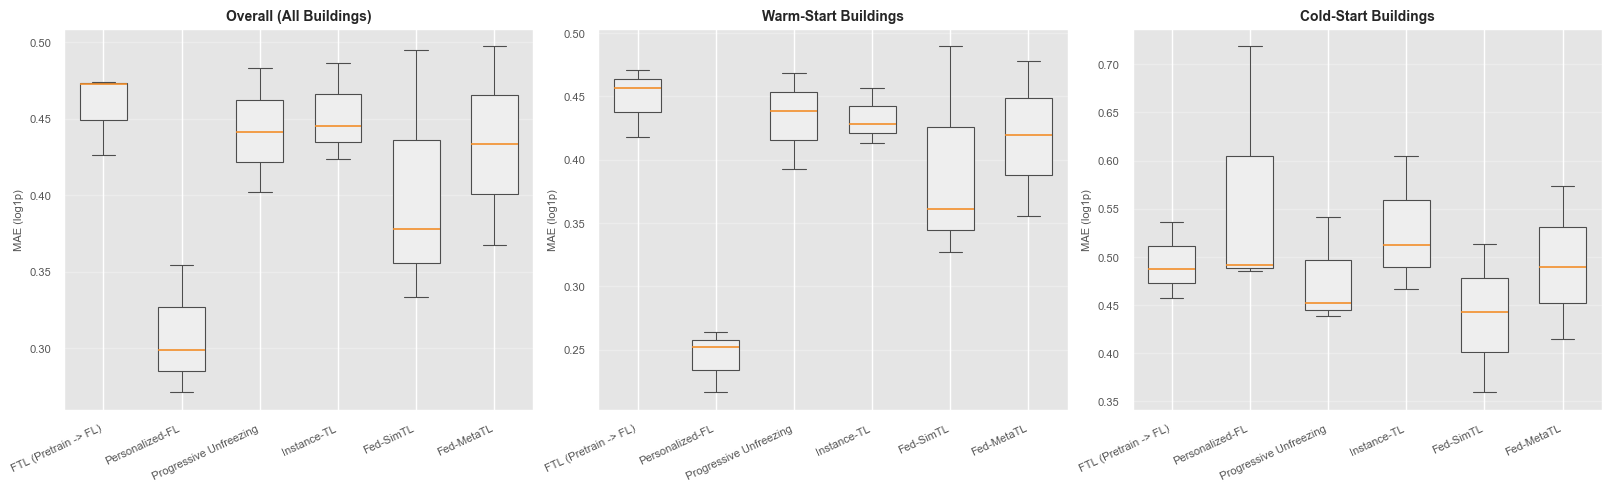

In [39]:
# C: Boxplot comparison of MAE (log1p) across six FTL strategies (all seeds) [PatchTST]
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

SEEDS = [42, 123, 2024]
SUMMARY_DIR = Path('saved_results')
OUT_FIG = SUMMARY_DIR / 'patchtst_all6_mae_log1p_boxplot_overall_warm_cold.png'
OUT_CSV = SUMMARY_DIR / 'patchtst_all6_mae_log1p_boxplot_source.csv'

STRATEGY_MAP = {
    '1. FTL': 'FTL (Pretrain -> FL)',
    '2. Personalized-FL': 'Personalized-FL',
    '3. Progressive Unfreezing': 'Progressive Unfreezing',
    '4. Instance-TL': 'Instance-TL',
    '5. Fed-SimTL': 'Fed-SimTL',
    '6. FedMetaTL': 'Fed-MetaTL',
}
ORDER_RAW = list(STRATEGY_MAP.keys())
ORDER = [STRATEGY_MAP[k] for k in ORDER_RAW]

rows = []
for seed in SEEDS:
    f = SUMMARY_DIR / f'patchtst_seed_{seed}_summary.csv'
    if not f.exists():
        print(f'Skipping missing file: {f}')
        continue
    d = pd.read_csv(f)
    d['strategy'] = d['strategy'].astype(str).str.strip()
    d = d[d['strategy'].isin(ORDER_RAW)].copy()
    d['strategy_display'] = d['strategy'].map(STRATEGY_MAP)
    d['seed'] = seed
    rows.append(d[['seed', 'strategy_display', 'overall_mae', 'warm_mae', 'cold_mae']])

if not rows:
    raise RuntimeError('No PatchTST summary rows found for requested seeds/strategies.')

plot_df = pd.concat(rows, ignore_index=True)
long_df = plot_df.melt(
    id_vars=['seed', 'strategy_display'],
    value_vars=['overall_mae', 'warm_mae', 'cold_mae'],
    var_name='split',
    value_name='mae_log1p',
)
long_df.to_csv(OUT_CSV, index=False)

panels = [
    ('overall_mae', 'Overall (All Buildings)'),
    ('warm_mae', 'Warm-Start Buildings'),
    ('cold_mae', 'Cold-Start Buildings'),
]

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

for ax, (split_key, title) in zip(axes, panels):
    sub = long_df[long_df['split'] == split_key].copy()
    grouped = [sub.loc[sub['strategy_display'] == s, 'mae_log1p'].dropna().values for s in ORDER]

    ax.boxplot(
        grouped,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        medianprops=dict(color='#f28e2b', linewidth=1.2),
        boxprops=dict(facecolor='#eeeeee', edgecolor='#4d4d4d', linewidth=0.8),
        whiskerprops=dict(color='#4d4d4d', linewidth=0.8),
        capprops=dict(color='#4d4d4d', linewidth=0.8),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='#7f7f7f', markeredgecolor='#7f7f7f', alpha=0.6),
    )

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(range(1, len(ORDER) + 1))
    ax.set_xticklabels(ORDER, rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('MAE (log1p)', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(True, axis='y', linestyle='-', alpha=0.3)

# fig.suptitle('PatchTST MAE (log1p) Boxplots Across 6 FTL Strategies (n=3 seeds)', fontsize=11, y=1.02)
fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()



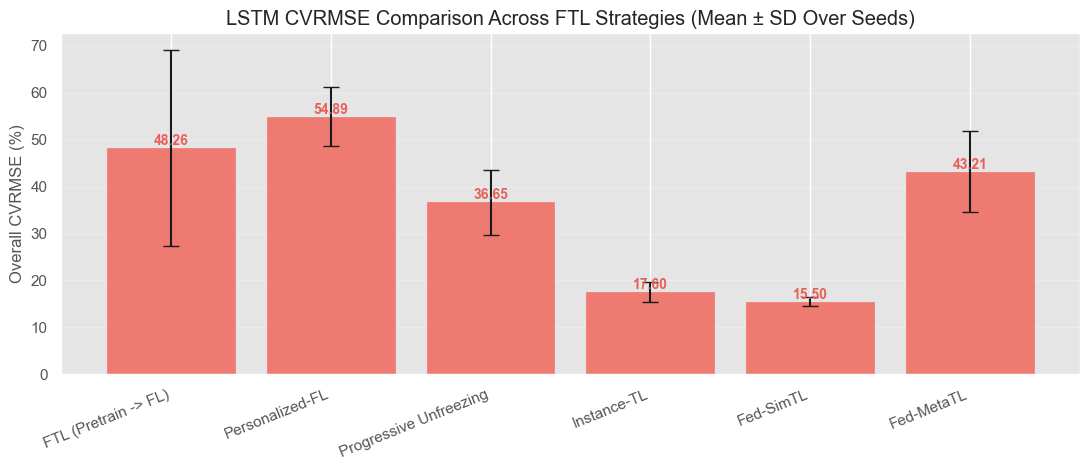

Saved aggregated CSV: saved_results\lstm_seed_agg_overall_cvrmse_ftl6.csv
Saved figure: saved_results\lstm_overall_cvrmse_mean_std_bar_ftl6.png


In [22]:
# LSTM CVRMSE across selected FTL strategies (mean ± std over seeds)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("saved_results")
SEEDS = [42, 123, 2024]

# Keep only the 6 FTL strategies (no centralized/local/fedavg)
DISPLAY_NAME_MAP = {
    "1. FTL": "FTL (Pretrain -> FL)",
    "2. Personalized-FL": "Personalized-FL",
    "3. Progressive Unfreezing": "Progressive Unfreezing",
    "4. Instance-TL": "Instance-TL",
    "5. Fed-SimTL": "Fed-SimTL",
    "6. FedMetaTL": "Fed-MetaTL",
}
DISPLAY_STRATEGIES = list(DISPLAY_NAME_MAP.keys())

rows = []
for seed in SEEDS:
    f = RESULTS_DIR / f"lstm_seed_{seed}_summary.csv"
    if not f.exists():
        print(f"Skipping missing file: {f}")
        continue

    d = pd.read_csv(f)
    d["strategy"] = d["strategy"].astype(str).str.strip()

    if "overall_cvrmse" not in d.columns:
        raise KeyError(f"'overall_cvrmse' missing in {f}")

    d = d[d["strategy"].isin(DISPLAY_STRATEGIES)][["strategy", "overall_cvrmse"]].copy()
    d["seed"] = seed
    rows.append(d)

if not rows:
    raise RuntimeError("No LSTM seed summary files found for selected strategies.")

raw_df = pd.concat(rows, ignore_index=True)

agg = (
    raw_df.groupby("strategy", as_index=False)["overall_cvrmse"]
    .agg(cvrmse_mean="mean", cvrmse_std=lambda x: x.std(ddof=1))
)

agg["cvrmse_std"] = agg["cvrmse_std"].fillna(0.0)
agg["strategy"] = pd.Categorical(agg["strategy"], categories=DISPLAY_STRATEGIES, ordered=True)
agg = agg.sort_values("strategy").reset_index(drop=True)
agg["strategy_display"] = agg["strategy"].map(DISPLAY_NAME_MAP)

out_csv = RESULTS_DIR / "lstm_seed_agg_overall_cvrmse_ftl6.csv"
agg.to_csv(out_csv, index=False)

plt.figure(figsize=(11, 4.8))
x = np.arange(len(agg))
y = agg["cvrmse_mean"].values
e = agg["cvrmse_std"].values

plt.bar(
    x, y, yerr=e, capsize=6,
    color="#ef746c", edgecolor="#ef746c", alpha=0.95
)

for xi, yi in zip(x, y):
    plt.text(
        xi, yi, f"{yi:.2f}",
        ha="center", va="bottom",
        fontsize=10, color="#e85f57", fontweight="bold"
    )

plt.xticks(x, agg["strategy_display"], rotation=22, ha="right")
plt.ylabel("Overall CVRMSE (%)")
plt.title("LSTM CVRMSE Comparison Across FTL Strategies (Mean ± SD Over Seeds)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

out_fig = RESULTS_DIR / "lstm_overall_cvrmse_mean_std_bar_ftl6.png"
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved aggregated CSV: {out_csv}")
print(f"Saved figure: {out_fig}")

Saved figure: saved_results\lstm_cold_days_sensitivity_ftl_all_seeds.png
Saved source data: saved_results\lstm_cold_days_sensitivity_ftl_all_seeds_source.csv


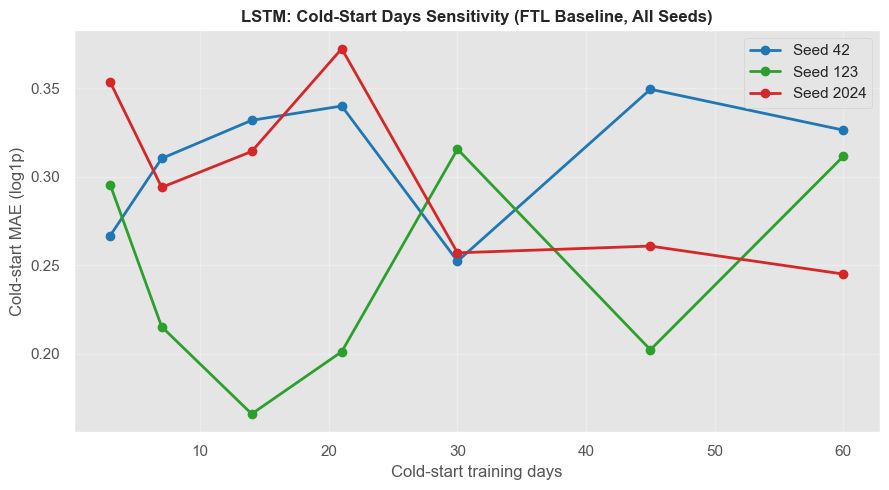

In [23]:
# LSTM: Cold-start days sensitivity (FTL baseline, all seeds)
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('saved_results')
SEEDS = [42, 123, 2024]
OUT_FIG = RESULTS_DIR / 'lstm_cold_days_sensitivity_ftl_all_seeds.png'
OUT_CSV = RESULTS_DIR / 'lstm_cold_days_sensitivity_ftl_all_seeds_source.csv'

rows = []
for seed in SEEDS:
    f = RESULTS_DIR / f'lstm_cold_days_sensitivity_ftl_seed{seed}.csv'
    if not f.exists():
        print(f'Skipping missing file: {f}')
        continue
    d = pd.read_csv(f)
    d.columns = [str(c).strip().lower() for c in d.columns]
    # expected fields from your existing exports
    # normalize naming if needed
    rename_map = {
        'cold_start_days': 'days',
        'cold_days': 'days',
        'mae': 'cold_mae',
        'cold_mae_log1p': 'cold_mae',
    }
    for src, dst in rename_map.items():
        if src in d.columns and dst not in d.columns:
            d = d.rename(columns={src: dst})

    if 'days' not in d.columns or 'cold_mae' not in d.columns:
        raise KeyError(f'Missing required columns in {f}. Found: {list(d.columns)}')

    d = d[['days', 'cold_mae']].copy()
    d['days'] = pd.to_numeric(d['days'], errors='coerce')
    d['cold_mae'] = pd.to_numeric(d['cold_mae'], errors='coerce')
    d = d.dropna(subset=['days', 'cold_mae']).sort_values('days')
    d['seed'] = seed
    rows.append(d)

if not rows:
    raise RuntimeError('No LSTM FTL cold-days sensitivity files found for requested seeds.')

plot_df = pd.concat(rows, ignore_index=True)
plot_df.to_csv(OUT_CSV, index=False)

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 5))
colors = {42: '#1f77b4', 123: '#2ca02c', 2024: '#d62728'}

for seed in sorted(plot_df['seed'].unique()):
    ds = plot_df[plot_df['seed'] == seed].sort_values('days')
    ax.plot(
        ds['days'],
        ds['cold_mae'],
        marker='o',
        linewidth=2,
        markersize=6,
        color=colors.get(seed, None),
        label=f'Seed {seed}'
    )

ax.set_title('LSTM: Cold-Start Days Sensitivity (FTL Baseline, All Seeds)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cold-start training days')
ax.set_ylabel('Cold-start MAE (log1p)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', frameon=True)

fig.tight_layout()
fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()



Saved figure: saved_results\lstm_cold_days_sensitivity_ftl_all_seeds_overall_warm_cold.png
Saved source data: saved_results\lstm_cold_days_sensitivity_ftl_all_seeds_overall_warm_cold_source.csv


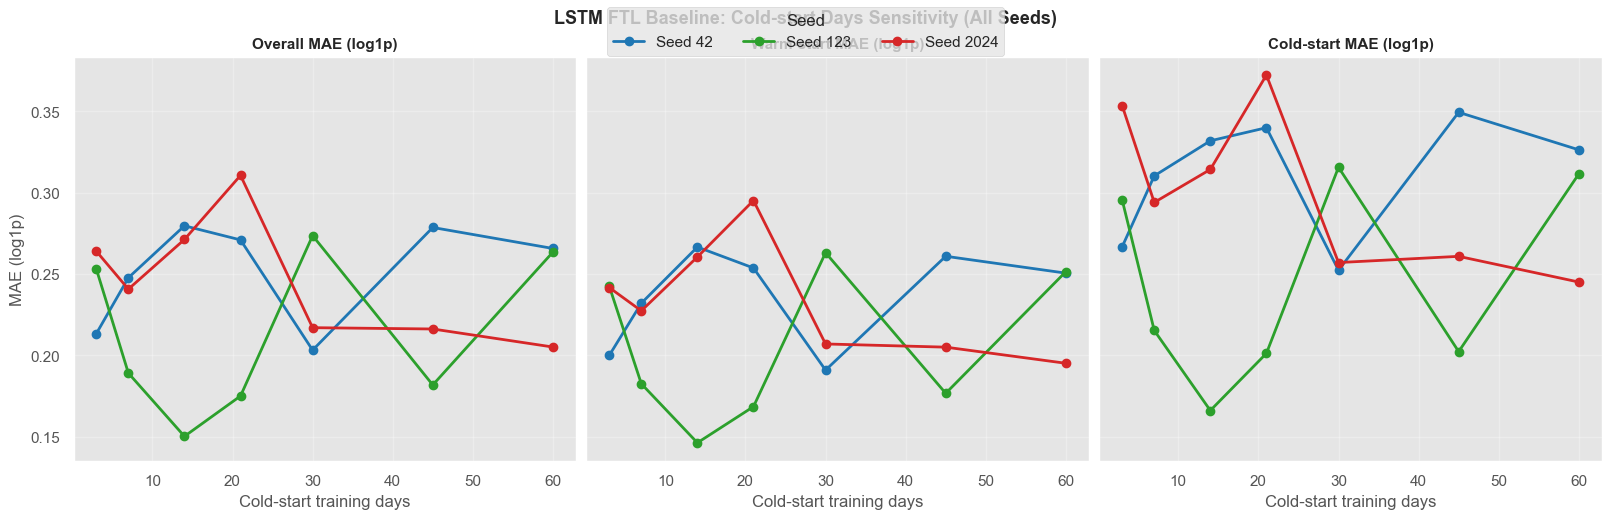

In [24]:
# LSTM: Cold-start days sensitivity (FTL baseline, all seeds) - Overall/Warm/Cold
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('saved_results')
SEEDS = [42, 123, 2024]
OUT_FIG = RESULTS_DIR / 'lstm_cold_days_sensitivity_ftl_all_seeds_overall_warm_cold.png'
OUT_CSV = RESULTS_DIR / 'lstm_cold_days_sensitivity_ftl_all_seeds_overall_warm_cold_source.csv'

rows = []
for seed in SEEDS:
    f = RESULTS_DIR / f'lstm_cold_days_sensitivity_ftl_seed{seed}.csv'
    if not f.exists():
        print(f'Skipping missing file: {f}')
        continue
    d = pd.read_csv(f)
    d.columns = [str(c).strip().lower() for c in d.columns]

    rename_map = {
        'cold_start_days': 'days',
        'cold_days': 'days',
        'mae': 'cold_mae',
        'cold_mae_log1p': 'cold_mae',
    }
    for src, dst in rename_map.items():
        if src in d.columns and dst not in d.columns:
            d = d.rename(columns={src: dst})

    required = ['days', 'overall_mae', 'warm_mae', 'cold_mae']
    miss = [c for c in required if c not in d.columns]
    if miss:
        raise KeyError(f'Missing columns {miss} in {f}. Found: {list(d.columns)}')

    d = d[required].copy()
    d['days'] = pd.to_numeric(d['days'], errors='coerce')
    for c in ['overall_mae', 'warm_mae', 'cold_mae']:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna(subset=['days']).sort_values('days')
    d['seed'] = seed
    rows.append(d)

if not rows:
    raise RuntimeError('No LSTM FTL cold-days sensitivity files found for requested seeds.')

plot_df = pd.concat(rows, ignore_index=True)
plot_df.to_csv(OUT_CSV, index=False)

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True, constrained_layout=True)
colors = {42: '#1f77b4', 123: '#2ca02c', 2024: '#d62728'}
panels = [
    ('overall_mae', 'Overall MAE (log1p)'),
    ('warm_mae', 'Warm-start MAE (log1p)'),
    ('cold_mae', 'Cold-start MAE (log1p)'),
]

for ax, (metric, title) in zip(axes, panels):
    for seed in sorted(plot_df['seed'].unique()):
        ds = plot_df[plot_df['seed'] == seed].sort_values('days')
        ax.plot(
            ds['days'], ds[metric],
            marker='o', linewidth=2, markersize=6,
            color=colors.get(seed, None), label=f'Seed {seed}'
        )
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cold-start training days')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('MAE (log1p)')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, frameon=True, title='Seed')
fig.suptitle('LSTM FTL Baseline: Cold-start Days Sensitivity (All Seeds)', fontsize=13, fontweight='bold', y=1.05)

fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()



Saved figure: saved_results\lstm_ftl_cold_days_combined_all_seeds_mae_cvrmse.png
Saved source data: saved_results\lstm_ftl_cold_days_combined_all_seeds_source.csv


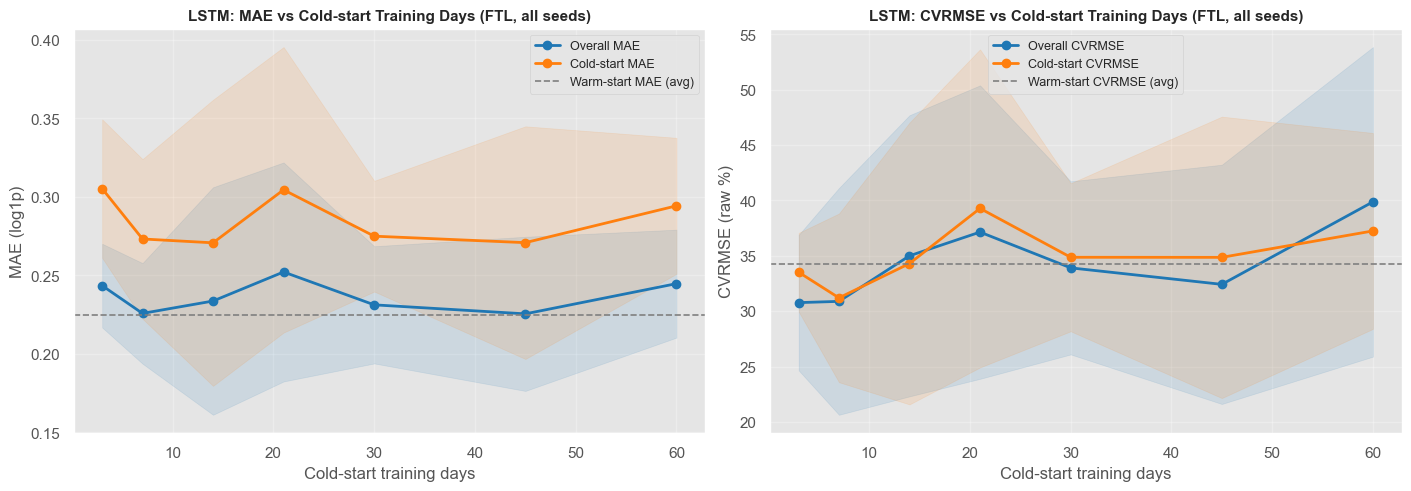

In [40]:
# LSTM FTL: MAE/CVRMSE vs cold-start days (combined across all seeds)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('saved_results')
SEEDS = [42, 123, 2024]
OUT_FIG = RESULTS_DIR / 'lstm_ftl_cold_days_combined_all_seeds_mae_cvrmse.png'
OUT_CSV = RESULTS_DIR / 'lstm_ftl_cold_days_combined_all_seeds_source.csv'

rows = []
for seed in SEEDS:
    f = RESULTS_DIR / f'lstm_cold_days_sensitivity_ftl_seed{seed}.csv'
    if not f.exists():
        print(f'Skipping missing file: {f}')
        continue
    d = pd.read_csv(f)
    d.columns = [str(c).strip().lower() for c in d.columns]

    rename_map = {
        'cold_start_days': 'days',
        'cold_days': 'days',
        'mae': 'cold_mae',
        'cv_rmse': 'overall_cvrmse',
        'cold_cv_rmse': 'cold_cvrmse',
    }
    for src, dst in rename_map.items():
        if src in d.columns and dst not in d.columns:
            d = d.rename(columns={src: dst})

    required = ['days', 'overall_mae', 'warm_mae', 'cold_mae', 'overall_cvrmse', 'cold_cvrmse']
    miss = [c for c in required if c not in d.columns]
    if miss:
        raise KeyError(f'Missing columns {miss} in {f}. Found: {list(d.columns)}')

    d = d[required].copy()
    d['seed'] = seed
    for c in required:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna(subset=['days']).sort_values('days')
    rows.append(d)

if not rows:
    raise RuntimeError('No LSTM FTL cold-days sensitivity files found.')

raw_df = pd.concat(rows, ignore_index=True)

agg = (
    raw_df.groupby('days', as_index=False)
    .agg(
        overall_mae_mean=('overall_mae', 'mean'),
        overall_mae_std=('overall_mae', lambda x: x.std(ddof=1)),
        cold_mae_mean=('cold_mae', 'mean'),
        cold_mae_std=('cold_mae', lambda x: x.std(ddof=1)),
        warm_mae_mean=('warm_mae', 'mean'),
        overall_cvrmse_mean=('overall_cvrmse', 'mean'),
        overall_cvrmse_std=('overall_cvrmse', lambda x: x.std(ddof=1)),
        cold_cvrmse_mean=('cold_cvrmse', 'mean'),
        cold_cvrmse_std=('cold_cvrmse', lambda x: x.std(ddof=1)),
        warm_cvrmse_mean=('cold_cvrmse', 'mean'),
    )
)

# Warm CVRMSE average should come from warm split if available.
if 'warm_cvrmse' in raw_df.columns:
    warm_cv = raw_df.groupby('days', as_index=False)['warm_cvrmse'].mean().rename(columns={'warm_cvrmse':'warm_cvrmse_mean'})
    agg = agg.drop(columns=['warm_cvrmse_mean']).merge(warm_cv, on='days', how='left')
else:
    # fallback if warm_cvrmse not exported: approximate with overall_cvrmse mean for reference line
    agg['warm_cvrmse_mean'] = agg['overall_cvrmse_mean']

for c in ['overall_mae_std','cold_mae_std','overall_cvrmse_std','cold_cvrmse_std']:
    agg[c] = agg[c].fillna(0.0)

agg = agg.sort_values('days').reset_index(drop=True)
agg.to_csv(OUT_CSV, index=False)

x = agg['days'].values

plt.style.use('ggplot')
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)

# Panel 1: MAE
ax = axes[0]
ax.plot(x, agg['overall_mae_mean'], marker='o', linewidth=2, label='Overall MAE', color='#1f77b4')
ax.fill_between(x, agg['overall_mae_mean']-agg['overall_mae_std'], agg['overall_mae_mean']+agg['overall_mae_std'], color='#1f77b4', alpha=0.12)
ax.plot(x, agg['cold_mae_mean'], marker='o', linewidth=2, label='Cold-start MAE', color='#ff7f0e')
ax.fill_between(x, agg['cold_mae_mean']-agg['cold_mae_std'], agg['cold_mae_mean']+agg['cold_mae_std'], color='#ff7f0e', alpha=0.12)
ax.axhline(agg['warm_mae_mean'].mean(), linestyle='--', color='gray', linewidth=1.2, label='Warm-start MAE (avg)')
ax.set_title('LSTM: MAE vs Cold-start Training Days (FTL, all seeds)', fontsize=11, fontweight='bold')
ax.set_xlabel('Cold-start training days')
ax.set_ylabel('MAE (log1p)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=True, fontsize=9)

# Panel 2: CVRMSE
ax = axes[1]
ax.plot(x, agg['overall_cvrmse_mean'], marker='o', linewidth=2, label='Overall CVRMSE', color='#1f77b4')
ax.fill_between(x, agg['overall_cvrmse_mean']-agg['overall_cvrmse_std'], agg['overall_cvrmse_mean']+agg['overall_cvrmse_std'], color='#1f77b4', alpha=0.12)
ax.plot(x, agg['cold_cvrmse_mean'], marker='o', linewidth=2, label='Cold-start CVRMSE', color='#ff7f0e')
ax.fill_between(x, agg['cold_cvrmse_mean']-agg['cold_cvrmse_std'], agg['cold_cvrmse_mean']+agg['cold_cvrmse_std'], color='#ff7f0e', alpha=0.12)
ax.axhline(agg['warm_cvrmse_mean'].mean(), linestyle='--', color='gray', linewidth=1.2, label='Warm-start CVRMSE (avg)')
ax.set_title('LSTM: CVRMSE vs Cold-start Training Days (FTL, all seeds)', fontsize=11, fontweight='bold')
ax.set_xlabel('Cold-start training days')
ax.set_ylabel('CVRMSE (raw %)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=True, fontsize=9)

fig.savefig(OUT_FIG, dpi=300, bbox_inches='tight')
print(f'Saved figure: {OUT_FIG}')
print(f'Saved source data: {OUT_CSV}')
plt.show()

